# 02 — Real Row Scaling

**Benchmark:** Benchmark 1 — Real Data Row Scaling  
**Scope:** Real Amazon Reviews row-count benchmark, từ `1M` đến `50M` rows.  
**Frameworks:** Pandas, Polars eager, Polars lazy, Dask.

Notebook này không chạy benchmark workload. Notebook chỉ đọc kết quả đã sinh trong `results/raw/` và phân tích khả năng scale khi số dòng tăng trên cùng loại dữ liệu real.

Khác với notebook `03_physical_scaling.ipynb`, notebook này không xem `dataset_size` như kích thước GB vật lý. Ở đây `dataset_size` là nhãn row count (`1M`, `10M`, `50M`), nên các phân tích chính tập trung vào runtime theo số dòng, throughput, memory trên mỗi triệu dòng, slowdown so với `1M`, và độ ổn định ranking khi row count tăng.


## 1. Research Questions

Notebook này trả lời năm câu hỏi chính:

1. Runtime của từng framework thay đổi như thế nào khi dữ liệu real tăng từ `1M` lên `10M` và `50M` rows?
2. Framework nào giữ throughput tốt nhất khi số dòng tăng?
3. Workload nào scale gần tuyến tính, workload nào có dấu hiệu super-linear slowdown?
4. Ranking giữa Pandas, Polars eager, Polars lazy và Dask có ổn định qua các row count không?
5. Có trade-off đáng kể giữa runtime và peak memory khi chọn framework cho real data không?


## 2. Setup and Data Loading

Code dùng key và tên biến tiếng Anh để khớp với CSV benchmark. Nội dung markdown dùng tiếng Việt để giải thích kết quả.


In [25]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() in {"benchmark", "benchmarks", "analysis", "report", "data_prep"}:
    PROJECT_ROOT = PROJECT_ROOT.parent.parent.resolve()
elif PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

RESULTS_DIR = PROJECT_ROOT / "results" / "raw"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "notebook_02_real_row_scaling"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RESULT_FILES = [
    RESULTS_DIR / "pandas_real_results.csv",
    RESULTS_DIR / "polars_real_results.csv",
    RESULTS_DIR / "polars_eager_real_results.csv",
    RESULTS_DIR / "dask_real_results.csv",
]

ROW_ORDER = ["1M", "10M", "50M"]
MAIN_WORKLOADS = ["filter", "groupby"]
STRESS_WORKLOADS = ["join", "pipeline"]
WORKLOAD_ORDER = MAIN_WORKLOADS + STRESS_WORKLOADS
FRAMEWORK_ORDER = ["pandas", "polars_lazy", "polars_eager", "dask"]

print(f"Project root : {PROJECT_ROOT}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"Figure dir   : {FIGURE_DIR}")


Project root : D:\Polar vs Dask
Results dir  : D:\Polar vs Dask\results\raw
Figure dir   : D:\Polar vs Dask\results\figures\notebook_02_real_row_scaling


In [26]:
available_files = [path for path in RESULT_FILES if path.exists()]
missing_files = [path.name for path in RESULT_FILES if not path.exists()]

if missing_files:
    print("Missing files:", missing_files)

if not available_files:
    raise FileNotFoundError("No real row-scaling result files found in results/raw/.")

frames = []
for path in available_files:
    frame = pd.read_csv(path)
    frame["source_file"] = path.name
    frames.append(frame)

df_raw = pd.concat(frames, ignore_index=True)

required_columns = {
    "timestamp", "framework", "workload", "dataset_size", "n_rows",
    "run_index", "time_s", "peak_memory_mb", "throughput_rows_per_s", "status",
}
missing_columns = sorted(required_columns - set(df_raw.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df_raw["dataset_size"] = pd.Categorical(df_raw["dataset_size"].astype(str), categories=ROW_ORDER, ordered=True)
df_raw["workload"] = pd.Categorical(df_raw["workload"].astype(str), categories=WORKLOAD_ORDER, ordered=True)
df_raw["framework"] = pd.Categorical(df_raw["framework"].astype(str), categories=FRAMEWORK_ORDER, ordered=True)
df_raw["row_count_m"] = df_raw["n_rows"] / 1_000_000

display(df_raw.head())
print(f"Rows loaded: {len(df_raw):,}")
print("Available row-count labels:", list(df_raw["dataset_size"].dropna().astype(str).unique()))


,timestamp,framework,workload,dataset_size,n_rows,run_index,time_s,peak_memory_mb,throughput_rows_per_s,status,notes,source_file,row_count_m
0,2026-05-08T02:07:16,pandas,filter,1M,1000000,1,2.0275,1342.21,493218,ok,NaN,pandas_real_results.csv,1.0
1,2026-05-08T02:07:18,pandas,filter,1M,1000000,2,2.1043,1369.80,475211,ok,NaN,pandas_real_results.csv,1.0
2,2026-05-08T02:07:20,pandas,filter,1M,1000000,3,2.0252,1356.99,493779,ok,NaN,pandas_real_results.csv,1.0
3,2026-05-08T02:07:25,pandas,groupby,1M,1000000,1,2.6655,1371.59,375165,ok,NaN,pandas_real_results.csv,1.0
4,2026-05-08T02:07:28,pandas,groupby,1M,1000000,2,2.6789,1386.44,373286,ok,NaN,pandas_real_results.csv,1.0


Rows loaded: 144
Available row-count labels: ['1M', '10M', '50M']


## 3. Workload Semantics

Các workload trong notebook này là **end-to-end dataframe workloads**, không phải microbenchmark operator cô lập.  
Mỗi workload bao gồm đọc parquet, thực thi phép biến đổi, và materialize kết quả cuối trong Python hoặc trong engine tương ứng.

Do đó, runtime của mỗi workload không chỉ phản ánh tốc độ của một operator đơn lẻ. Nó còn bao gồm:

- parquet scan / read,
- parquet decoding,
- column projection hoặc predicate pushdown nếu framework hỗ trợ,
- execution planning hoặc scheduler overhead,
- memory allocation,
- intermediate result construction,
- final result materialization.

| Workload | Semantics | Key columns | Output behavior | Practical interpretation |
|---|---|---|---|---|
| `filter` | Lọc review có `rating >= FILTER_RATING_THRESHOLD` | `rating` | Có thể vẫn lớn nếu nhiều dòng thỏa điều kiện | Scan/filter-heavy workload; lợi cho engine có predicate pushdown, lazy scan, hoặc parallel read tốt. Nếu output lớn, chi phí materialization có thể chiếm đáng kể runtime và memory. |
| `groupby` | Group theo `GROUPBY_COLUMN` và tính `mean`, `count`, `sum` của `rating` | `parent_asin`, `rating` | Thường nhỏ hơn input vì kết quả được aggregate theo key | Aggregation-heavy workload; runtime phụ thuộc vào cardinality, hash-table cost và skew của key. Vì output thường nhỏ hơn input, workload này có thể ổn định hơn filter hoặc join ở dataset lớn. |
| `join` | Left join reviews với product metadata trên `parent_asin` | `parent_asin`, metadata `price`, `brand` | Output thường gần kích thước input và có thêm cột metadata | Join/materialization-heavy workload; có thể tạo memory pressure vì phải giữ hoặc xây dựng bảng join, xử lý key matching, và materialize output lớn. |
| `pipeline` | `filter -> groupby -> join metadata -> sort` | `rating`, `parent_asin`, `price`, `brand` | Output phụ thuộc vào mức filter và số group còn lại | Query thực tế nhiều bước; lợi cho engine tối ưu plan, column projection, giảm intermediate data và xử lý aggregation hiệu quả. Đây là workload gần với analytical query thực tế hơn một operator đơn lẻ. |

Trong cấu hình hiện tại, `GROUPBY_COLUMN` và join key thực tế là `parent_asin`. Vì vậy `groupby`, `join` và `pipeline` đều chịu ảnh hưởng mạnh từ **cardinality** và **skew** của product key trong dữ liệu real.

Tuy nhiên, ba workload này không nên được hiểu là đang đo cùng một hiện tượng:

- `groupby` chủ yếu đo chi phí aggregation theo key và kích thước hash table.
- `join` chủ yếu đo chi phí key matching và materialize bảng kết quả lớn.
- `pipeline` đo khả năng tối ưu toàn bộ query plan, đặc biệt là việc giảm intermediate data trước khi join hoặc sort.

Vì vậy, khi diễn giải kết quả, cần tránh kết luận đơn giản như “framework A join nhanh nên groupby cũng phải nhanh”. Mỗi workload tạo ra áp lực khác nhau lên CPU, I/O, memory, scheduler và optimizer.

## 4. Dataset Footprint Sanity Check

Row scaling kiểm soát biến chính là số dòng, nhưng dung lượng parquet trên disk vẫn cần được kiểm tra. Nếu bytes/row thay đổi mạnh giữa `1M`, `10M` và `50M`, throughput và memory không nên được diễn giải như chỉ phụ thuộc vào row count.


In [27]:
DATASET_DIR = PROJECT_ROOT / "data" / "benchmark_real"

footprint_rows = []
for label in ROW_ORDER:
    dataset_path = DATASET_DIR / label
    parquet_files = sorted(dataset_path.glob("*.parquet")) if dataset_path.exists() else []
    total_bytes = sum(path.stat().st_size for path in parquet_files)

    metadata_rows = np.nan
    metadata_error = None
    if parquet_files:
        try:
            import pyarrow.parquet as pq
            metadata_rows = sum(pq.ParquetFile(path).metadata.num_rows for path in parquet_files)
        except Exception as exc:
            metadata_error = str(exc)

    benchmark_rows = df_raw.loc[df_raw["dataset_size"].astype(str) == label, "n_rows"].dropna()
    benchmark_n_rows = benchmark_rows.iloc[0] if not benchmark_rows.empty else np.nan

    footprint_rows.append({
        "dataset_size": label,
        "n_parquet_files": len(parquet_files),
        "parquet_size_gb": total_bytes / (1024 ** 3),
        "metadata_n_rows": metadata_rows,
        "benchmark_n_rows": benchmark_n_rows,
        "bytes_per_row_on_disk": total_bytes / metadata_rows if metadata_rows and metadata_rows > 0 else np.nan,
        "row_count_matches_log": bool(metadata_rows == benchmark_n_rows) if pd.notna(metadata_rows) and pd.notna(benchmark_n_rows) else np.nan,
        "metadata_error": metadata_error,
    })

footprint = pd.DataFrame(footprint_rows)
display(footprint.round(4))


,dataset_size,n_parquet_files,parquet_size_gb,metadata_n_rows,benchmark_n_rows,bytes_per_row_on_disk,row_count_matches_log,metadata_error
0,1M,2,0.1610,1000000,1000000,172.8330,True,None
1,10M,14,1.4392,10000000,10000000,154.5310,True,None
2,50M,66,6.9906,50000000,50000000,150.1229,True,None


### Sanity Check Interpretation

Bảng này kiểm tra hai điều chính:

1. Số dòng đọc từ parquet metadata có khớp với `n_rows` trong benchmark log hay không.
2. Dung lượng parquet trên disk tăng như thế nào khi row count tăng từ `1M` lên `10M` và `50M`.

Tất cả các mức dữ liệu đều có `row_count_matches_log = True`, nghĩa là số dòng trong parquet metadata khớp với số dòng được ghi trong benchmark log. Vì vậy, notebook có thể dùng `n_rows` trong CSV làm biến chính cho real row-scaling analysis.

Dung lượng parquet cũng tăng theo row count:

| Dataset | Rows | Parquet size | Bytes/row on disk |
|---|---:|---:|---:|
| `1M` | 1,000,000 | 0.1610 GB | 172.8330 |
| `10M` | 10,000,000 | 1.4392 GB | 154.5310 |
| `50M` | 50,000,000 | 6.9906 GB | 150.1229 |

Tuy nhiên, `bytes_per_row_on_disk` giảm nhẹ khi dataset lớn hơn. Điều này cho thấy physical footprint tăng gần tuyến tính theo row count, nhưng không hoàn toàn tuyến tính. Ví dụ, row count tăng từ `1M` lên `50M` là `50x`, trong khi parquet size tăng khoảng `43.4x`.

Điều này không làm mất giá trị của Benchmark 1, vì biến chính của benchmark này vẫn là **row count trên real data**. Tuy nhiên, khi diễn giải runtime và throughput, cần nhớ rằng kết quả không chỉ phản ánh số dòng, mà còn chịu ảnh hưởng bởi physical parquet size, compression ratio, số parquet files, row group layout, và I/O behavior.

Vì vậy, bảng này xác nhận rằng:

- `n_rows` là biến scaling hợp lệ cho Benchmark 1;
- physical dataset size tăng hợp lý theo row count;
- nhưng Benchmark 1 vẫn nên được diễn giải là **real row-scaling benchmark**, không phải physical-size-controlled benchmark.

## 5. Data Completeness Check

Trước khi diễn giải performance, cần kiểm tra số lần chạy thành công cho từng tổ hợp framework, workload và row count. Các phân tích runtime/memory chỉ dùng `status == "ok"`; failure được giữ riêng ở cuối notebook.


In [28]:
df_ok = df_raw[df_raw["status"] == "ok"].copy()
df_fail = df_raw[df_raw["status"] != "ok"].copy()

run_count = (
    df_raw
    .groupby(["framework", "workload", "dataset_size", "status"], observed=True)
    .size()
    .rename("n_runs")
    .reset_index()
)

display(run_count)


,framework,workload,dataset_size,status,n_runs
0,pandas,filter,1M,ok,3
1,pandas,filter,10M,ok,3
2,pandas,filter,50M,ok,3
3,pandas,groupby,1M,ok,3
4,pandas,groupby,10M,ok,3
5,pandas,groupby,50M,ok,3
6,pandas,join,1M,ok,3
7,pandas,join,10M,ok,3
8,pandas,join,50M,ok,3
9,pandas,pipeline,1M,ok,3


In [29]:
completion_matrix = (
    df_ok
    .groupby(["framework", "workload", "dataset_size"], observed=True)["run_index"]
    .count()
    .rename("successful_runs")
    .reset_index()
    .pivot_table(
        index=["framework", "workload"],
        columns="dataset_size",
        values="successful_runs",
        observed=True,
    )
)

display(completion_matrix)


dataset_size            1M  10M  50M
framework    workload               
pandas       filter    3.0  3.0  3.0
             groupby   3.0  3.0  3.0
             join      3.0  3.0  3.0
             pipeline  3.0  3.0  3.0
polars_lazy  filter    3.0  3.0  3.0
             groupby   3.0  3.0  3.0
             join      3.0  3.0  3.0
             pipeline  3.0  3.0  3.0
polars_eager filter    3.0  3.0  3.0
             groupby   3.0  3.0  3.0
             join      3.0  3.0  3.0
             pipeline  3.0  3.0  3.0
dask         filter    3.0  3.0  3.0
             groupby   3.0  3.0  3.0
             join      3.0  3.0  3.0
             pipeline  3.0  3.0  3.0

Dữ liệu hiện có đủ để so sánh row scaling vì mỗi tổ hợp `framework × workload × row_count` có 3 successful runs. Điều này cho phép dùng mean và standard deviation thay vì dựa vào một lần chạy đơn lẻ.

Tuy vậy, 3 runs vẫn là sample nhỏ. Các kết luận nên tập trung vào xu hướng lớn, ranking rõ ràng và khác biệt theo bậc độ lớn, thay vì diễn giải quá mạnh các chênh lệch nhỏ.

## 6. Summary Table

Bảng `summary` là nguồn chính cho các phân tích tiếp theo. Ngoài mean/std, bảng này thêm throughput theo triệu dòng/giây, peak memory theo GB, memory trên mỗi triệu dòng, và coefficient of variation.


In [30]:
summary = (
    df_ok
    .groupby(["framework", "workload", "dataset_size"], observed=True)
    .agg(
        mean_time_s=("time_s", "mean"),
        std_time_s=("time_s", "std"),
        mean_peak_memory_mb=("peak_memory_mb", "mean"),
        std_peak_memory_mb=("peak_memory_mb", "std"),
        mean_throughput_rows_per_s=("throughput_rows_per_s", "mean"),
        std_throughput_rows_per_s=("throughput_rows_per_s", "std"),
        mean_n_rows=("n_rows", "mean"),
        row_count_m=("row_count_m", "mean"),
        n_runs=("run_index", "count"),
    )
    .reset_index()
)

summary["mean_peak_memory_gb"] = summary["mean_peak_memory_mb"] / 1024
summary["std_peak_memory_gb"] = summary["std_peak_memory_mb"] / 1024
summary["mean_throughput_mrows_per_s"] = summary["mean_throughput_rows_per_s"] / 1_000_000
summary["std_throughput_mrows_per_s"] = summary["std_throughput_rows_per_s"] / 1_000_000
summary["memory_per_million_rows_gb"] = np.where(
    summary["row_count_m"] > 0,
    summary["mean_peak_memory_gb"] / summary["row_count_m"],
    np.nan,
)
summary["runtime_cv"] = np.where(summary["mean_time_s"] > 0, summary["std_time_s"] / summary["mean_time_s"], np.nan)
summary["memory_cv"] = np.where(summary["mean_peak_memory_gb"] > 0, summary["std_peak_memory_gb"] / summary["mean_peak_memory_gb"], np.nan)

summary = summary.sort_values(["dataset_size", "workload", "framework"]).reset_index(drop=True)
agg = summary

display(summary.round(4))


,framework,workload,dataset_size,mean_time_s,std_time_s,mean_peak_memory_mb,std_peak_memory_mb,mean_throughput_rows_per_s,std_throughput_rows_per_s,mean_n_rows,row_count_m,n_runs,mean_peak_memory_gb,std_peak_memory_gb,mean_throughput_mrows_per_s,std_throughput_mrows_per_s,memory_per_million_rows_gb,runtime_cv,memory_cv
0,pandas,filter,1M,2.0523,0.0450,1356.3333,13.8067,4.874027e+05,10562.0184,1000000.0,1.0,3,1.3245,0.0135,0.4874,0.0106,1.3245,0.0219,0.0102
1,polars_lazy,filter,1M,0.3709,0.0029,688.3600,16.6126,2.696172e+06,20903.4542,1000000.0,1.0,3,0.6722,0.0162,2.6962,0.0209,0.6722,0.0078,0.0241
2,polars_eager,filter,1M,0.3171,0.0081,763.8400,63.8857,3.155034e+06,79804.9867,1000000.0,1.0,3,0.7459,0.0624,3.1550,0.0798,0.7459,0.0257,0.0836
3,dask,filter,1M,0.6916,0.0117,1006.8433,36.8506,1.446202e+06,24508.9720,1000000.0,1.0,3,0.9832,0.0360,1.4462,0.0245,0.9832,0.0169,0.0366
4,pandas,groupby,1M,2.6339,0.0666,1381.7800,8.8355,3.798223e+05,9739.4194,1000000.0,1.0,3,1.3494,0.0086,0.3798,0.0097,1.3494,0.0253,0.0064
5,polars_lazy,groupby,1M,0.6238,0.0060,1418.7667,79.2609,1.603227e+06,15189.7455,1000000.0,1.0,3,1.3855,0.0774,1.6032,0.0152,1.3855,0.0096,0.0559
6,polars_eager,groupby,1M,0.4345,0.0004,829.1333,32.7679,2.301326e+06,2169.5881,1000000.0,1.0,3,0.8097,0.0320,2.3013,0.0022,0.8097,0.0009,0.0395
7,dask,groupby,1M,0.3180,0.0198,720.9033,0.0115,3.152860e+06,190188.1426,1000000.0,1.0,3,0.7040,0.0000,3.1529,0.1902,0.7040,0.0623,0.0000
8,pandas,join,1M,14.1695,2.6114,2845.4100,66.7963,7.240833e+04,14929.7255,1000000.0,1.0,3,2.7787,0.0652,0.0724,0.0149,2.7787,0.1843,0.0235
9,polars_lazy,join,1M,5.2984,1.5176,2261.9567,64.3070,1.981210e+05,49241.8533,1000000.0,1.0,3,2.2089,0.0628,0.1981,0.0492,2.2089,0.2864,0.0284


### Aggregated Results Interpretation

Bảng trên cung cấp cái nhìn tổng quan về runtime, peak memory và throughput cho từng tổ hợp `framework × workload × dataset_size`.  
Mỗi cấu hình có `3` lần chạy, nên các giá trị mean/std có thể được dùng để đánh giá cả hiệu năng trung bình lẫn độ ổn định của benchmark.

Kết quả cho thấy sự khác biệt giữa các framework trở nên rõ rệt khi dataset tăng lên `50M`. Pandas hoàn thành tất cả workload nhưng runtime tăng mạnh nhất, đặc biệt ở `filter`, `join` và `pipeline`. Ngược lại, Polars và Dask duy trì runtime thấp hơn đáng kể ở dataset lớn.

Ở `50M`, framework nhanh nhất thay đổi theo workload: `polars_lazy` nhanh nhất cho `filter` và `pipeline`, `dask` nhanh nhất cho `groupby`, còn `polars_eager` nhanh nhất cho `join`. Điều này cho thấy không có framework nào thắng tuyệt đối; lựa chọn framework phụ thuộc vào workload semantics.

Memory cũng cần được diễn giải cùng runtime. Một framework nhanh hơn không nhất thiết dùng ít memory hơn. Ví dụ, `polars_lazy` rất nhanh ở `50M filter` nhưng peak memory cao hơn `polars_eager`. Ngược lại, `dask` ở `50M groupby` vừa nhanh vừa tiết kiệm memory.

Vì vậy, bảng này nên được xem là overview cho phân tích tiếp theo. Các section sau sẽ tách riêng runtime scaling, throughput scaling, memory scaling và speedup so với Pandas để tránh kết luận quá sớm từ một bảng tổng hợp lớn.

## 7. Runtime Scaling

Runtime scaling là câu hỏi trung tâm của notebook này: khi số dòng tăng 50 lần từ `1M` lên `50M`, framework nào tăng runtime gần tuyến tính, framework nào tăng nhanh hơn nhiều?


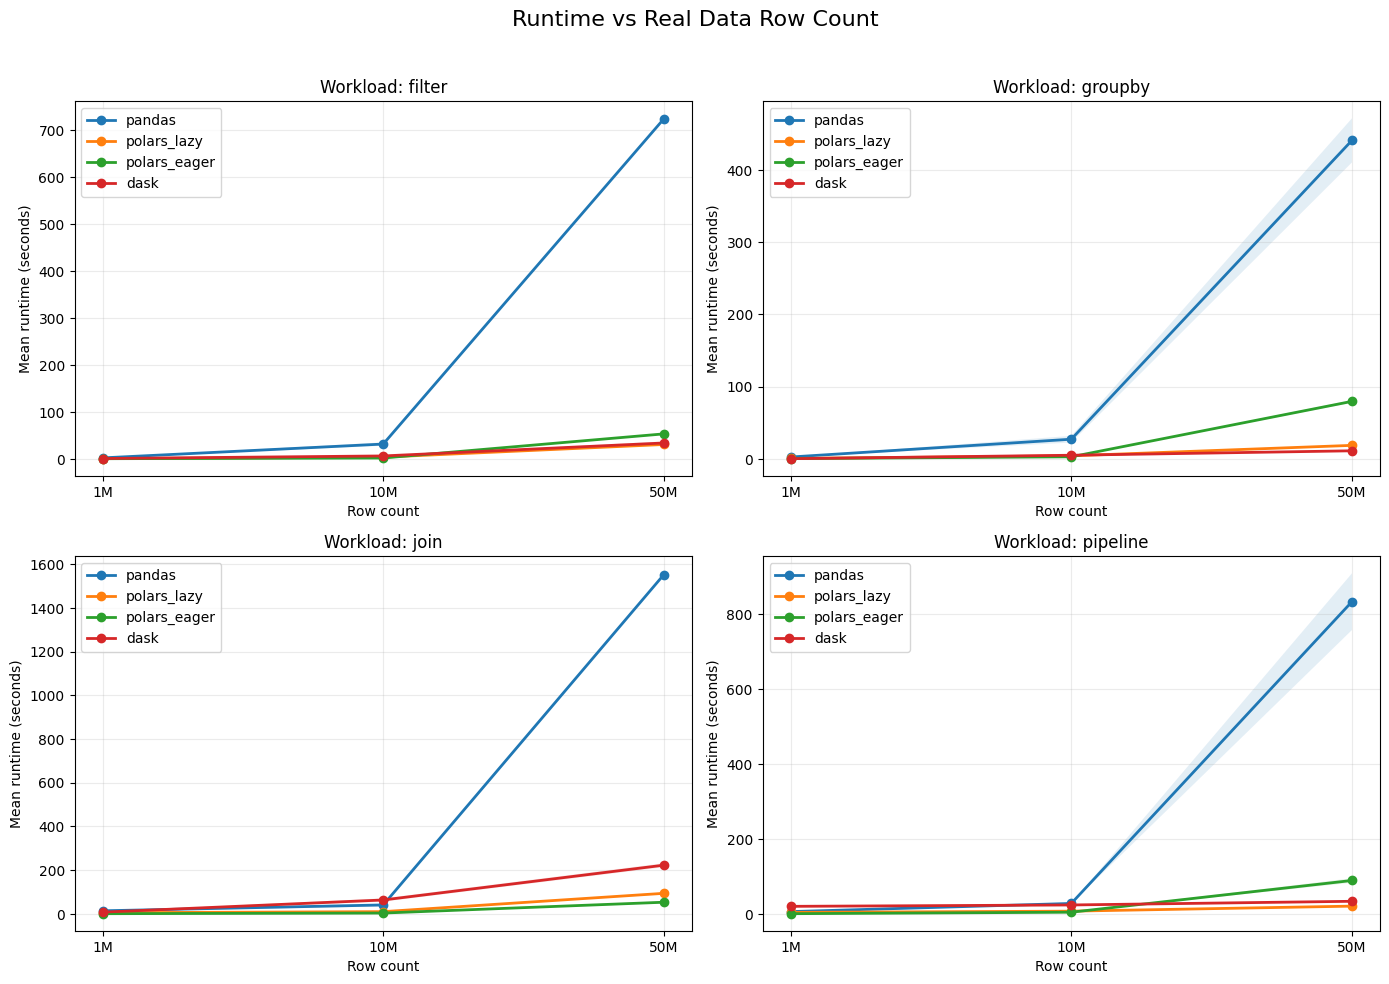

Saved: D:\Polar vs Dask\results\figures\notebook_02_real_row_scaling\runtime_vs_row_count_by_workload.png


In [31]:
def plot_metric_by_workload(data, metric, ylabel, title, filename, marker="o", log_y=False):
    workloads = [workload for workload in WORKLOAD_ORDER if workload in data["workload"].astype(str).unique()]

    n_cols = 2
    n_rows = int(np.ceil(len(workloads) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.8 * n_rows), squeeze=False)

    row_labels = [label for label in ROW_ORDER if label in data["dataset_size"].astype(str).unique()]
    row_to_x = {label: idx for idx, label in enumerate(row_labels)}

    for ax, workload in zip(axes.flat, workloads):
        subset = data[data["workload"].astype(str) == workload]

        for framework in FRAMEWORK_ORDER:
            group = subset[subset["framework"].astype(str) == framework].copy()
            if group.empty:
                continue

            group["row_label"] = group["dataset_size"].astype(str)
            group["x"] = group["row_label"].map(row_to_x)
            group = group.sort_values("x")

            x_values = group["x"].to_numpy()
            y_values = group[metric].to_numpy()

            ax.plot(x_values, y_values, marker=marker, linewidth=2, label=framework)

            std_column = metric.replace("mean_", "std_", 1)
            if std_column in group.columns and group[std_column].notna().any():
                lower = (group[metric] - group[std_column]).clip(lower=0).to_numpy()
                upper = (group[metric] + group[std_column]).to_numpy()
                ax.fill_between(x_values, lower, upper, alpha=0.12)

        ax.set_title(f"Workload: {workload}")
        ax.set_xlabel("Row count")
        ax.set_ylabel(ylabel)
        ax.set_xticks(range(len(row_labels)))
        ax.set_xticklabels(row_labels)
        ax.grid(True, alpha=0.25)
        if log_y:
            ax.set_yscale("log")
        ax.legend()

    for ax in axes.flat[len(workloads):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16, y=1.02)
    fig.tight_layout()

    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")


plot_metric_by_workload(
    summary,
    metric="mean_time_s",
    ylabel="Mean runtime (seconds)",
    title="Runtime vs Real Data Row Count",
    filename="runtime_vs_row_count_by_workload.png",
)


### Runtime vs Row Count Interpretation

Biểu đồ này so sánh **mean runtime** của từng framework khi real data tăng từ `1M` lên `10M` và `50M` rows.

Kết quả cho thấy runtime không tăng giống nhau giữa các framework. Ở quy mô nhỏ (`1M`), hầu hết framework hoàn thành workload trong thời gian tương đối ngắn, dù vẫn có khác biệt giữa Pandas, Polars và Dask. Khi dữ liệu tăng lên `50M`, khác biệt trở nên rất rõ: Pandas tăng runtime mạnh nhất trong cả bốn workload, đặc biệt ở `filter`, `join` và `pipeline`.

Ở mức `50M`, framework nhanh nhất phụ thuộc vào workload:

| Workload | Fastest framework at 50M | Interpretation |
|---|---|---|
| `filter` | `polars_lazy` | Có lợi từ lazy scan, predicate pushdown hoặc giảm work trước khi materialize. |
| `groupby` | `dask` | Aggregation theo partition xử lý tốt trong cấu hình hiện tại. |
| `join` | `polars_eager` | Eager execution hiệu quả hơn cho join/materialization-heavy workload này. |
| `pipeline` | `polars_lazy` | Multi-step query hưởng lợi từ plan optimization và giảm intermediate data. |

Điểm quan trọng là **không có framework nào thắng tuyệt đối trên mọi workload**. Kết quả runtime phụ thuộc mạnh vào workload semantics: `filter` thiên về scan/predicate, `groupby` thiên về aggregation, `join` thiên về materialization, còn `pipeline` kiểm tra khả năng tối ưu chuỗi thao tác nhiều bước.

Biểu đồ này dùng linear y-axis, nên runtime rất lớn của Pandas ở `50M` có thể làm các đường Polars và Dask trông sát nhau hơn thực tế. Vì vậy, các phần tiếp theo cần xem thêm throughput, slowdown ratio, speedup vs Pandas và memory để diễn giải đầy đủ hơn.

In [ ]:
runtime_ranking = (
    summary
    .assign(runtime_rank=lambda data: data.groupby(["workload", "dataset_size"], observed=True)["mean_time_s"].rank(method="min"))
    .sort_values(["workload", "dataset_size", "runtime_rank"])
    [["workload", "dataset_size", "framework", "mean_time_s", "std_time_s", "runtime_rank"]]
)

display(runtime_ranking.round(3))

,workload,dataset_size,framework,mean_time_s,std_time_s,runtime_rank
2,filter,1M,polars_eager,0.317,0.008,1.0
1,filter,1M,polars_lazy,0.371,0.003,2.0
3,filter,1M,dask,0.692,0.012,3.0
0,filter,1M,pandas,2.052,0.045,4.0
18,filter,10M,polars_eager,1.793,0.075,1.0
17,filter,10M,polars_lazy,3.633,0.149,2.0
19,filter,10M,dask,6.198,0.171,3.0
16,filter,10M,pandas,31.514,3.656,4.0
33,filter,50M,polars_lazy,30.594,1.291,1.0
35,filter,50M,dask,33.803,3.318,2.0


### Runtime Ranking Interpretation

Bảng ranking cho thấy thứ hạng runtime phụ thuộc mạnh vào cả **workload semantics** và **dataset scale**. Không có framework nào giữ vị trí nhanh nhất cho mọi workload và mọi kích thước dữ liệu.

Ở các dataset nhỏ hơn (`1M` và `10M`), `polars_eager` thường đứng đầu trong nhiều workload, đặc biệt là `filter`, `join`, và `pipeline`. Điều này cho thấy eager execution có overhead thấp và rất hiệu quả khi dữ liệu còn vừa phải.

Tuy nhiên, khi dữ liệu tăng lên `50M`, ranking thay đổi rõ rệt:

| Workload | Fastest framework at 50M | Mean runtime |
|---|---|---:|
| `filter` | `polars_lazy` | ~30.59s |
| `groupby` | `dask` | ~11.24s |
| `join` | `polars_eager` | ~53.40s |
| `pipeline` | `polars_lazy` | ~21.17s |

Điểm quan trọng của row-scaling benchmark không chỉ là framework nào nhanh nhất tại `1M`, mà là framework nào còn giữ được runtime hợp lý khi dữ liệu tăng lên `50M`. Theo tiêu chí đó, Pandas là baseline thực tế nhưng không phải lựa chọn tốt cho dataset lớn trong benchmark này, vì Pandas đứng cuối ở tất cả workload tại `50M`.

Kết quả cũng cho thấy ranking không nên được diễn giải như một kết luận tuyệt đối về framework. Ví dụ, `polars_lazy` thắng ở `filter` và `pipeline`, nhưng không thắng ở `join`; `dask` rất mạnh ở `groupby`, nhưng không phải lựa chọn tốt nhất cho `join`; còn `polars_eager` vẫn là lựa chọn tốt nhất cho join-heavy workload trong cấu hình hiện tại.

Vì vậy, ranking này nên được dùng để nhấn mạnh rằng lựa chọn framework phụ thuộc vào workload cụ thể, scale dữ liệu, và trade-off giữa execution strategy, materialization cost, scheduler overhead và memory behavior.

## 8. Throughput Scaling

Throughput chuẩn hóa runtime theo số dòng:

`throughput = n_rows / runtime`

Metric này trả lời câu hỏi framework xử lý được bao nhiêu triệu dòng mỗi giây khi row count tăng. Nếu throughput giảm mạnh ở `50M`, framework có thể đang gặp overhead, memory pressure, hoặc workload amplification.


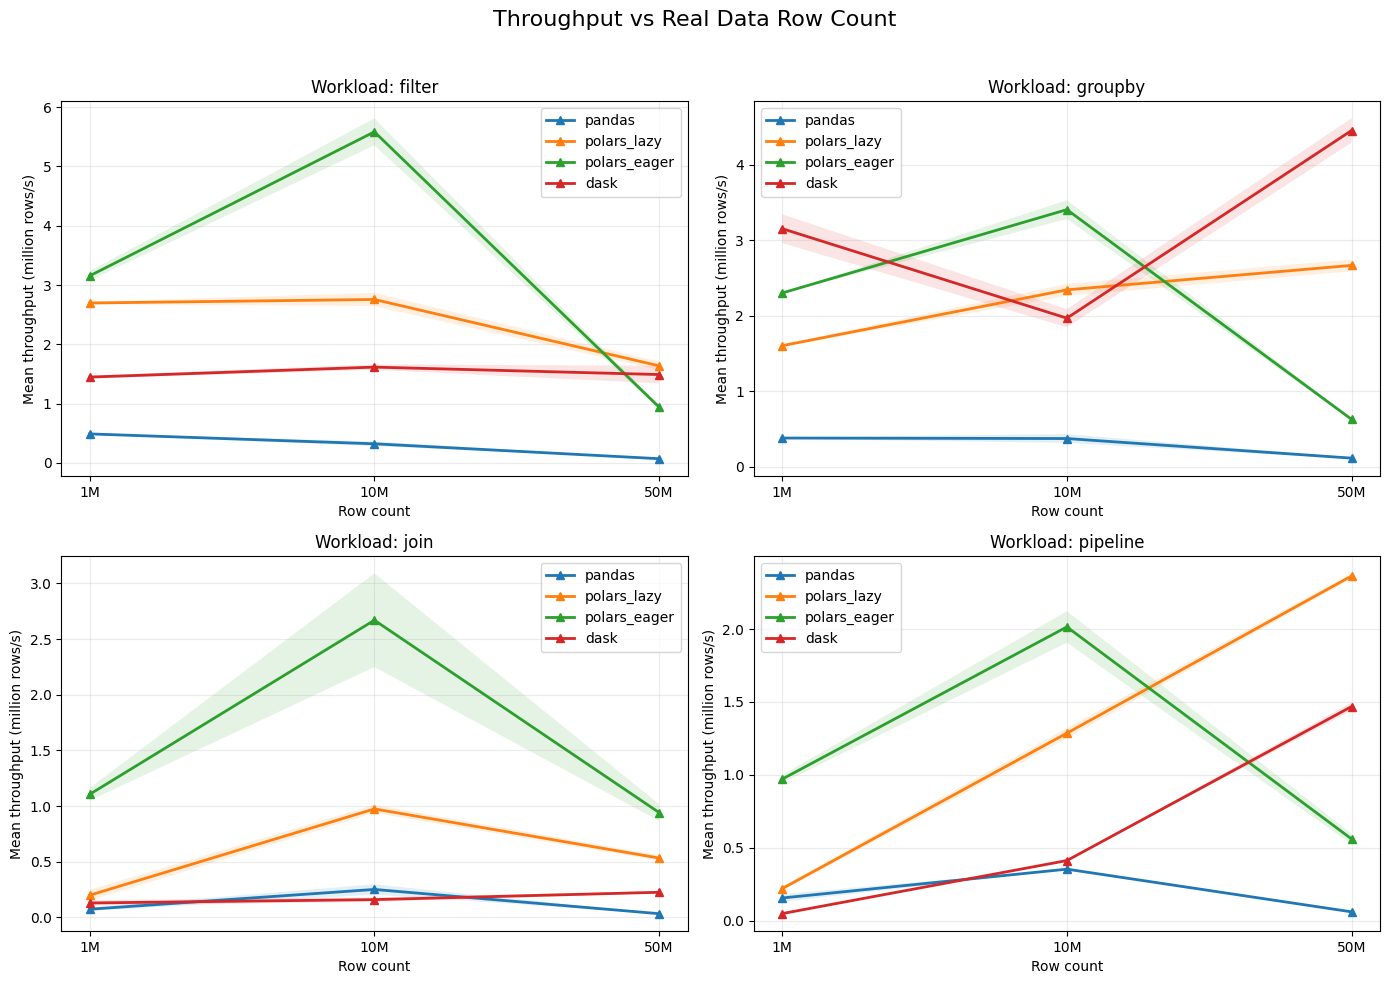

Saved: D:\Polar vs Dask\results\figures\notebook_02_real_row_scaling\throughput_vs_row_count_by_workload.png


,workload,dataset_size,framework,mean_throughput_mrows_per_s,throughput_rank
2,filter,1M,polars_eager,3.155,1.0
1,filter,1M,polars_lazy,2.696,2.0
3,filter,1M,dask,1.446,3.0
0,filter,1M,pandas,0.487,4.0
18,filter,10M,polars_eager,5.584,1.0
17,filter,10M,polars_lazy,2.756,2.0
19,filter,10M,dask,1.614,3.0
16,filter,10M,pandas,0.320,4.0
33,filter,50M,polars_lazy,1.636,1.0
35,filter,50M,dask,1.489,2.0


In [33]:
plot_metric_by_workload(
    summary,
    metric="mean_throughput_mrows_per_s",
    ylabel="Mean throughput (million rows/s)",
    title="Throughput vs Real Data Row Count",
    filename="throughput_vs_row_count_by_workload.png",
    marker="^",
)

throughput_ranking = (
    summary
    .assign(throughput_rank=lambda data: data.groupby(["workload", "dataset_size"], observed=True)["mean_throughput_mrows_per_s"].rank(method="min", ascending=False))
    .sort_values(["workload", "dataset_size", "throughput_rank"])
    [["workload", "dataset_size", "framework", "mean_throughput_mrows_per_s", "throughput_rank"]]
)

display(throughput_ranking.round(3))


### Throughput Interpretation

Throughput chuẩn hóa runtime theo số dòng xử lý mỗi giây, nên giúp nhìn rõ hơn khả năng scale thực tế của từng framework khi row count tăng. Một framework có thể nhanh ở `1M` do overhead thấp, nhưng throughput có thể giảm ở dataset lớn nếu workload tạo nhiều memory pressure, intermediate data hoặc final materialization cost.

Kết quả cho thấy throughput phụ thuộc mạnh vào workload và scale dữ liệu. Ở `1M` và `10M`, `polars_eager` thường có throughput cao trong nhiều workload, đặc biệt là `filter`, `join` và `pipeline`. Tuy nhiên, tại `50M`, ranking thay đổi rõ rệt:

| Workload | Highest throughput at 50M | Throughput |
|---|---|---:|
| `filter` | `polars_lazy` | ~1.64 M rows/s |
| `groupby` | `dask` | ~4.45 M rows/s |
| `join` | `polars_eager` | ~0.94 M rows/s |
| `pipeline` | `polars_lazy` | ~2.36 M rows/s |

Điều này phù hợp với runtime ranking: `polars_lazy` dẫn đầu ở `filter` và `pipeline`, `dask` dẫn đầu ở `groupby`, còn `polars_eager` dẫn đầu ở `join`.

Một điểm đáng chú ý là throughput không luôn tăng khi dataset lớn hơn. Ví dụ, `polars_eager` đạt throughput rất cao ở `10M filter`, nhưng giảm mạnh tại `50M`. Điều này cho thấy ở scale lớn hơn, chi phí memory, materialization hoặc I/O có thể bắt đầu chi phối workload. Ngược lại, `dask` ở `groupby` đạt throughput cao nhất tại `50M`, cho thấy workload aggregation này phù hợp hơn với cách xử lý partitioned trong cấu hình benchmark hiện tại.

Vì vậy, throughput nên được đọc cùng với runtime và memory. Throughput cao cho thấy framework xử lý nhiều dòng mỗi giây, nhưng không tự nó giải thích nguyên nhân. Các phần memory scaling và speedup tiếp theo cần được dùng để phân biệt giữa lợi thế do engine execution, lazy optimization, partitioned execution, hay khác biệt về materialization cost.

## 9. Memory Scaling

Peak memory là metric độc lập với runtime. Trên row scaling, memory không nên chỉ đọc theo GB tuyệt đối; cần xem thêm memory trên mỗi triệu dòng để đánh giá framework nào tăng memory hiệu quả hơn khi row count tăng.


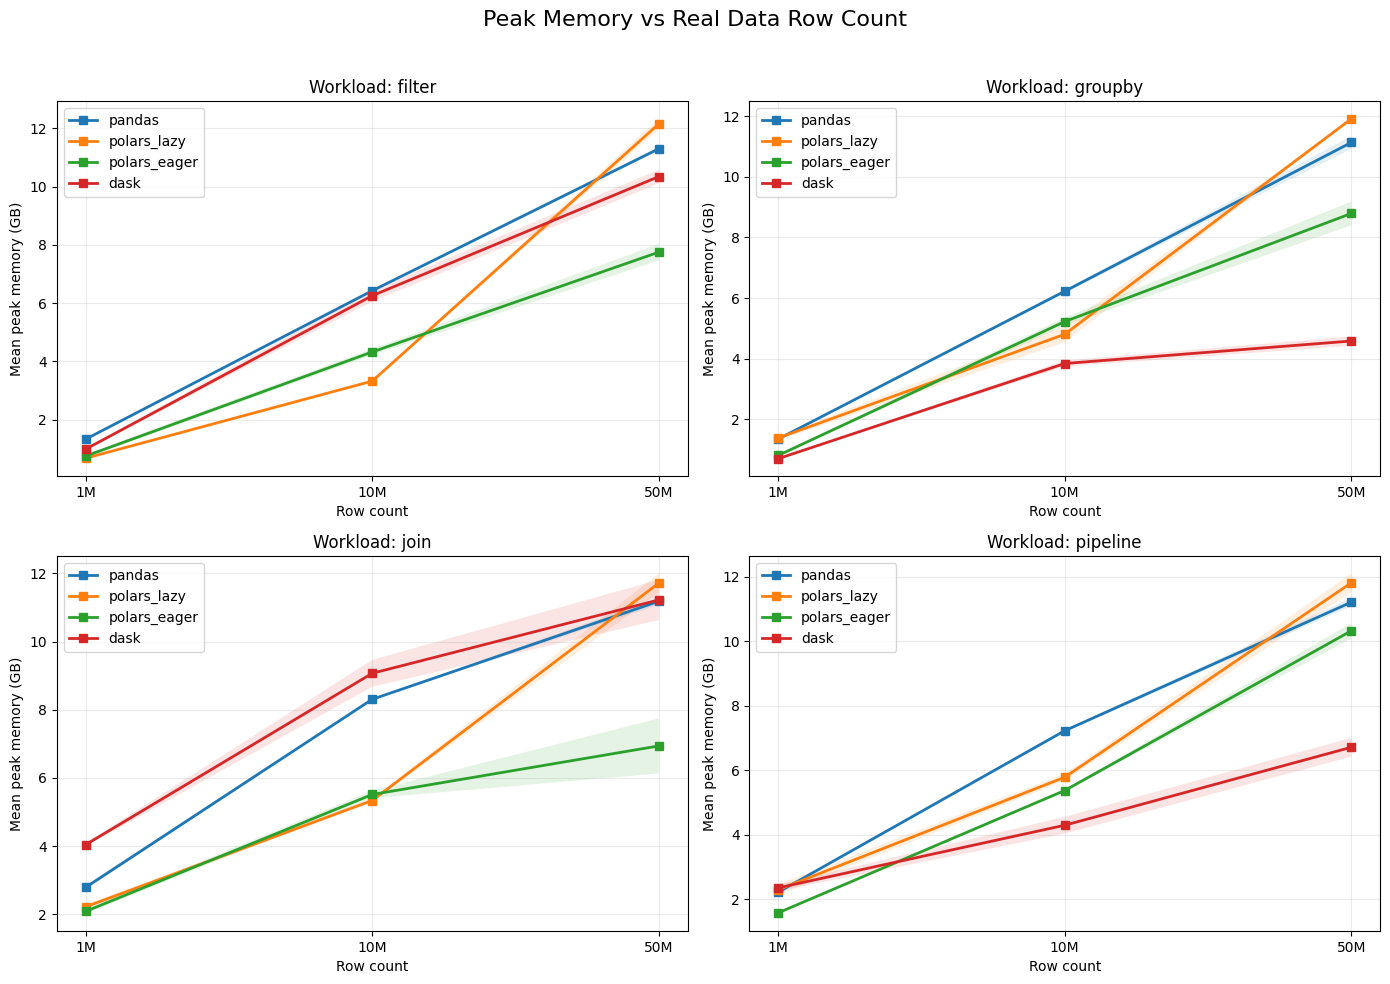

Saved: D:\Polar vs Dask\results\figures\notebook_02_real_row_scaling\memory_vs_row_count_by_workload.png


,workload,dataset_size,framework,mean_peak_memory_gb,memory_per_million_rows_gb,memory_rank
1,filter,1M,polars_lazy,0.672,0.672,1.0
2,filter,1M,polars_eager,0.746,0.746,2.0
3,filter,1M,dask,0.983,0.983,3.0
0,filter,1M,pandas,1.325,1.325,4.0
17,filter,10M,polars_lazy,3.319,0.332,1.0
18,filter,10M,polars_eager,4.320,0.432,2.0
19,filter,10M,dask,6.252,0.625,3.0
16,filter,10M,pandas,6.422,0.642,4.0
34,filter,50M,polars_eager,7.747,0.155,1.0
35,filter,50M,dask,10.341,0.207,2.0


In [34]:
plot_metric_by_workload(
    summary,
    metric="mean_peak_memory_gb",
    ylabel="Mean peak memory (GB)",
    title="Peak Memory vs Real Data Row Count",
    filename="memory_vs_row_count_by_workload.png",
    marker="s",
)

memory_ranking = (
    summary
    .assign(memory_rank=lambda data: data.groupby(["workload", "dataset_size"], observed=True)["mean_peak_memory_gb"].rank(method="min"))
    .sort_values(["workload", "dataset_size", "memory_rank"])
    [["workload", "dataset_size", "framework", "mean_peak_memory_gb", "memory_per_million_rows_gb", "memory_rank"]]
)

display(memory_ranking.round(3))


### Peak Memory Interpretation

Peak memory cho thấy runtime nhanh không luôn đồng nghĩa với memory thấp. Vì benchmark này là end-to-end, peak memory phản ánh toàn bộ quá trình đọc parquet, decode dữ liệu, thực thi workload, tạo intermediate data và materialize kết quả cuối, chứ không phải memory footprint thuần của một operator đơn lẻ.

Ở `50M`, nhiều workload tiến gần vùng `10–12 GB` peak memory, đặc biệt khi workload cần materialize nhiều dữ liệu hoặc tạo intermediate result lớn. Điều này dễ thấy ở `filter`, `join`, và `pipeline`, nơi output hoặc intermediate data có thể lớn hơn nhiều so với `groupby`.

Ranking memory cũng khác với ranking runtime. Ví dụ:

| Workload at 50M | Fastest framework | Lowest-memory framework |
|---|---|---|
| `filter` | `polars_lazy` | `polars_eager` |
| `groupby` | `dask` | `dask` |
| `join` | `polars_eager` | `polars_eager` |
| `pipeline` | `polars_lazy` | `dask` |

Điều này cho thấy cần đọc runtime và memory cùng nhau. `polars_lazy` rất mạnh về runtime trong `filter` và `pipeline`, nhưng ở `50M` lại có peak memory cao nhất trong hai workload này. Ngược lại, `dask` nổi bật ở `groupby` vì vừa nhanh nhất vừa dùng ít memory nhất, còn `polars_eager` là lựa chọn tốt nhất cho `join` trong cả runtime lẫn memory ở `50M`.

Cần đọc peak memory một cách thận trọng: metric này có thể bị ảnh hưởng bởi cách đo RSS/process memory, native allocation của Polars, worker/task execution của Dask, cache của runtime, garbage collection, và thời điểm materialize kết quả. Vì Pandas, Polars và Dask có mô hình thực thi khác nhau, peak memory phù hợp để so sánh **áp lực tài nguyên end-to-end** hơn là so sánh trực tiếp memory allocator nội bộ.

## 10. Memory per Million Rows

Metric chuẩn hóa:

`memory_per_million_rows_gb = mean_peak_memory_gb / row_count_m`

Nếu metric này giảm khi row count tăng, framework đang amortize overhead tốt hơn trên input lớn. Nếu metric tăng hoặc giữ cao, framework có thể bị intermediate materialization hoặc memory pressure.


,framework,workload,dataset_size,row_count_m,mean_peak_memory_gb,memory_per_million_rows_gb
1,polars_lazy,filter,1M,1.0,0.6722,0.6722
2,polars_eager,filter,1M,1.0,0.7459,0.7459
3,dask,filter,1M,1.0,0.9832,0.9832
0,pandas,filter,1M,1.0,1.3245,1.3245
17,polars_lazy,filter,10M,10.0,3.3189,0.3319
18,polars_eager,filter,10M,10.0,4.3202,0.4320
19,dask,filter,10M,10.0,6.2518,0.6252
16,pandas,filter,10M,10.0,6.4223,0.6422
34,polars_eager,filter,50M,50.0,7.7469,0.1549
35,dask,filter,50M,50.0,10.3410,0.2068


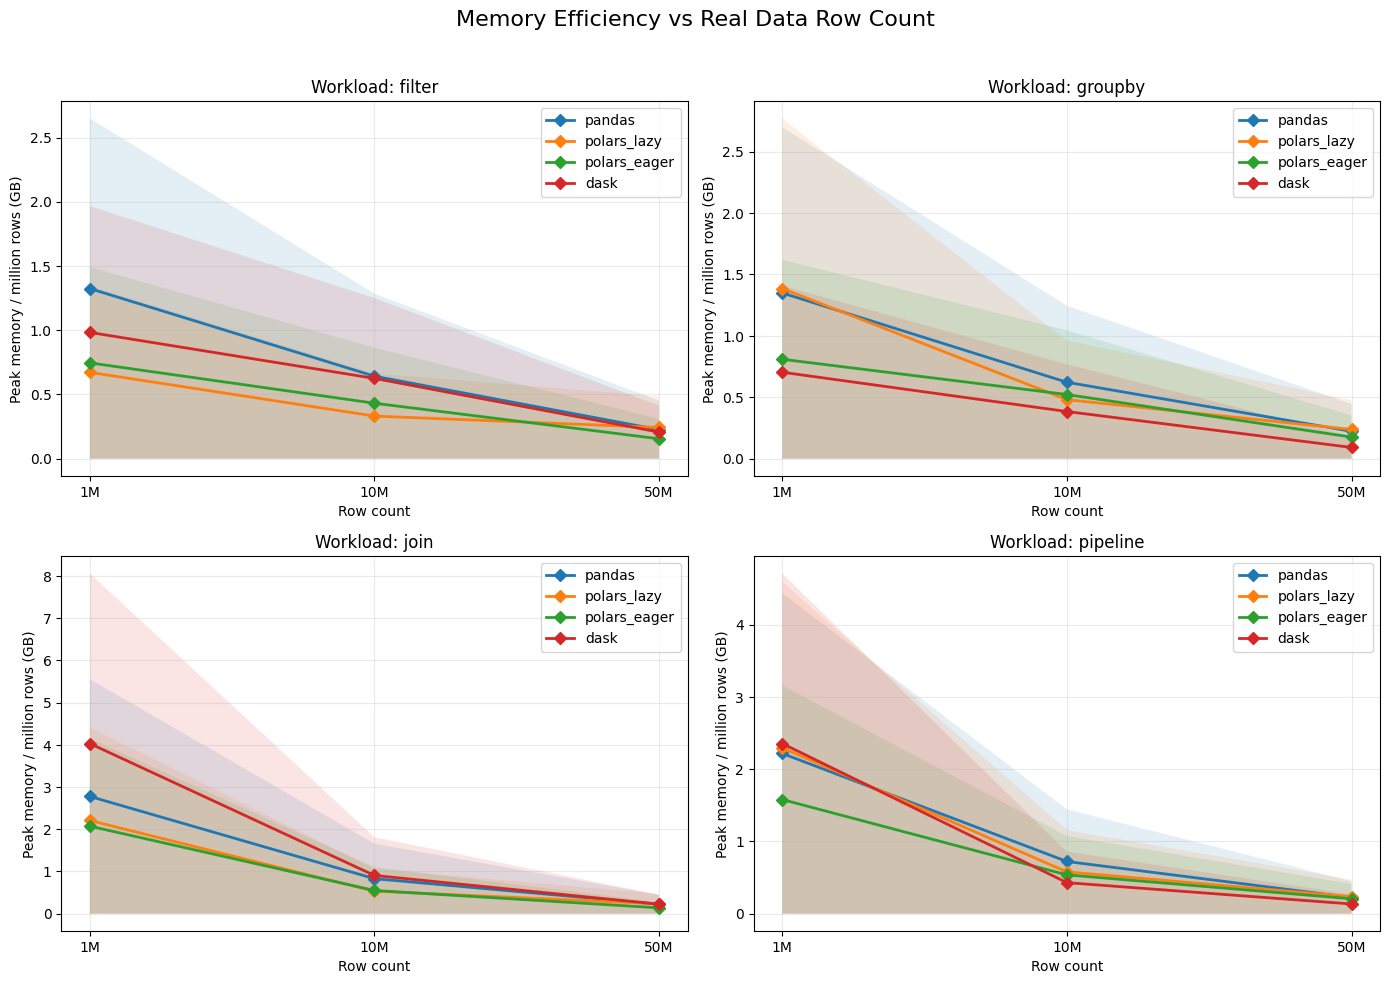

Saved: D:\Polar vs Dask\results\figures\notebook_02_real_row_scaling\memory_per_million_rows_by_workload.png


In [35]:
memory_efficiency = (
    summary
    .sort_values(["workload", "row_count_m", "memory_per_million_rows_gb"])
    [["framework", "workload", "dataset_size", "row_count_m", "mean_peak_memory_gb", "memory_per_million_rows_gb"]]
)

display(memory_efficiency.round(4))

plot_metric_by_workload(
    summary,
    metric="memory_per_million_rows_gb",
    ylabel="Peak memory / million rows (GB)",
    title="Memory Efficiency vs Real Data Row Count",
    filename="memory_per_million_rows_by_workload.png",
    marker="D",
)


### Memory Efficiency Interpretation

Biểu đồ này chuẩn hóa peak memory theo số triệu dòng dữ liệu, tức là đo `GB / million rows`. Metric này giúp phân biệt giữa hai hiện tượng: peak memory tuyệt đối tăng khi dataset lớn hơn, và memory efficiency có cải thiện hay không khi framework xử lý nhiều dòng hơn.

Kết quả cho thấy `memory_per_million_rows_gb` thường giảm mạnh từ `1M` lên `10M` và tiếp tục giảm ở `50M`. Điều này là hợp lý vì nhiều chi phí cố định như khởi tạo framework, đọc metadata, scheduler/runtime overhead, allocation ban đầu, và cấu trúc dữ liệu phụ trợ được amortize trên nhiều dòng hơn.

Vì vậy, memory scaling không nên được đánh giá chỉ bằng peak memory tuyệt đối. Một framework có peak memory cao ở `50M` nhưng memory per million rows giảm mạnh vẫn có thể đang scale hợp lý về mặt memory efficiency.

Tuy nhiên, metric này cũng cần được đọc thận trọng. `GB / million rows` không có nghĩa là mỗi một triệu dòng thật sự chiếm đúng lượng memory đó một cách độc lập. Đây là chỉ số chuẩn hóa end-to-end, chịu ảnh hưởng bởi read/decode parquet, intermediate data, output materialization, cache, native allocation và execution model của từng framework.

Một số insight chính từ bảng và biểu đồ:

- Memory efficiency cải thiện rõ khi scale từ `1M` lên `50M`, do fixed overhead được amortize.
- `join` và `pipeline` có memory per million rows cao hơn ở dataset nhỏ vì workload tạo nhiều intermediate hoặc output materialization hơn.
- Ở `50M`, `dask` có memory efficiency tốt trong `groupby` và `pipeline`.
- Ở `50M join`, `polars_eager` có memory per million rows thấp nhất, phù hợp với việc nó cũng là framework nhanh nhất cho join trong cấu hình này.
- `polars_lazy` nhanh nhất ở `50M filter` và `50M pipeline`, nhưng không phải luôn memory-efficient nhất theo metric này.

Do đó, memory efficiency nên được dùng như một chỉ báo bổ sung cho peak memory, không thay thế peak memory. Peak memory cho biết workload có thể vượt giới hạn RAM hay không, còn memory per million rows giúp đánh giá framework có tận dụng scale tốt hơn khi dataset lớn lên hay không.1

## 11. Slowdown Ratio vs 1M

Slowdown ratio so sánh runtime của từng row count với baseline `1M` trong cùng framework và workload:

`runtime_slowdown_ratio = mean_time_s(size) / mean_time_s(1M)`

Vì input tăng 50 lần từ `1M` lên `50M`, slowdown gần 50 lần có thể xem là gần tuyến tính trong range này. Slowdown lớn hơn nhiều gợi ý super-linear behavior; thấp hơn nhiều có thể do fixed overhead ở dataset nhỏ hoặc execution model scale tốt hơn khi input lớn.


In [36]:
available_row_order = [size for size in ROW_ORDER if size in summary["dataset_size"].astype(str).unique()]
BASELINE_SIZE = "1M" if "1M" in available_row_order else available_row_order[0]

baseline = (
    summary[summary["dataset_size"].astype(str) == BASELINE_SIZE]
    [["framework", "workload", "mean_time_s", "mean_peak_memory_gb"]]
    .rename(columns={
        "mean_time_s": "baseline_time_s",
        "mean_peak_memory_gb": "baseline_peak_memory_gb",
    })
)

summary_ratio = summary.merge(baseline, on=["framework", "workload"], how="left")
summary_ratio["runtime_slowdown_ratio"] = summary_ratio["mean_time_s"] / summary_ratio["baseline_time_s"]
summary_ratio["memory_growth_ratio"] = summary_ratio["mean_peak_memory_gb"] / summary_ratio["baseline_peak_memory_gb"]

baseline_rows = summary.loc[summary["dataset_size"].astype(str) == BASELINE_SIZE, "row_count_m"].min()
summary_ratio["row_growth_ratio"] = summary_ratio["row_count_m"] / baseline_rows
summary_ratio["slowdown_per_row_growth"] = summary_ratio["runtime_slowdown_ratio"] / summary_ratio["row_growth_ratio"]

slowdown_table = summary_ratio.pivot_table(
    index=["framework", "workload"],
    columns="dataset_size",
    values="runtime_slowdown_ratio",
    observed=True,
)
memory_growth_table = summary_ratio.pivot_table(
    index=["framework", "workload"],
    columns="dataset_size",
    values="memory_growth_ratio",
    observed=True,
)

print(f"Baseline row count: {BASELINE_SIZE}")
display(slowdown_table.round(2))
display(memory_growth_table.round(2))


Baseline row count: 1M


dataset_size            1M    10M     50M
framework    workload                    
pandas       filter    1.0  15.36  352.94
             groupby   1.0  10.36  167.37
             join      1.0   2.89  109.58
             pipeline  1.0   4.31  126.53
polars_lazy  filter    1.0   9.79   82.48
             groupby   1.0   6.85   30.08
             join      1.0   1.94   17.77
             pipeline  1.0   1.71    4.64
polars_eager filter    1.0   5.65  167.78
             groupby   1.0   6.76  183.29
             join      1.0   4.20   58.86
             pipeline  1.0   4.83   86.82
dask         filter    1.0   8.96   48.88
             groupby   1.0  16.02   35.34
             join      1.0   7.95   27.86
             pipeline  1.0   1.18    1.65

dataset_size            1M   10M    50M
framework    workload                  
pandas       filter    1.0  4.85   8.53
             groupby   1.0  4.61   8.25
             join      1.0  2.99   4.02
             pipeline  1.0  3.26   5.06
polars_lazy  filter    1.0  4.94  18.08
             groupby   1.0  3.47   8.60
             join      1.0  2.41   5.30
             pipeline  1.0  2.52   5.15
polars_eager filter    1.0  5.79  10.39
             groupby   1.0  6.45  10.86
             join      1.0  2.66   3.34
             pipeline  1.0  3.40   6.53
dask         filter    1.0  6.36  10.52
             groupby   1.0  5.46   6.51
             join      1.0  2.25   2.78
             pipeline  1.0  1.82   2.85

### What this means

So với baseline `1M`, Pandas có slowdown rất lớn ở `50M`, đặc biệt `filter` và `pipeline`. Điều này cho thấy Pandas không chỉ tăng runtime theo số dòng, mà còn bị khuếch đại bởi chi phí memory/materialization khi input lớn.
### Runtime and Memory Growth vs 1M

Hai bảng trên so sánh mức tăng tương đối so với baseline `1M`.

Bảng thứ nhất đo **runtime slowdown**, tức là runtime tại `10M` hoặc `50M` lớn gấp bao nhiêu lần so với runtime tại `1M`.  
Bảng thứ hai đo **peak memory growth**, tức là peak memory tại `10M` hoặc `50M` lớn gấp bao nhiêu lần so với peak memory tại `1M`.

Kết quả cho thấy runtime và memory không tăng theo cùng một tốc độ. Ở `50M`, Pandas có runtime slowdown rất lớn, đặc biệt ở `filter`, `groupby`, `join` và `pipeline`. Ví dụ, `filter` chậm hơn khoảng `353x`, `groupby` khoảng `167x`, `join` khoảng `110x`, và `pipeline` khoảng `127x` so với `1M`. Điều này cho thấy Pandas không chỉ tăng runtime theo số dòng, mà còn bị ảnh hưởng mạnh bởi memory pressure, materialization cost, và overhead khi dữ liệu lớn.

Trong khi đó, memory growth của Pandas thấp hơn nhiều so với runtime slowdown. Ví dụ, peak memory của Pandas tại `50M` chỉ tăng khoảng `4x–8.5x` tùy workload, trong khi runtime có thể tăng hơn `100x`. Điều này cho thấy runtime degradation không thể được giải thích chỉ bằng peak memory tuyệt đối; execution strategy, intermediate materialization, cache/pagefile behavior, và data movement cũng có thể đóng vai trò lớn.

Polars và Dask nhìn chung giữ runtime slowdown thấp hơn Pandas, nhưng hành vi khác nhau theo workload. `polars_lazy` có slowdown rất thấp ở `pipeline` tại `50M` khoảng `4.64x`, cho thấy multi-step pipeline có thể hưởng lợi từ lazy optimization và giảm intermediate data. `dask` cũng có slowdown thấp ở `pipeline`, khoảng `1.65x`, nhưng cần đọc cùng workload semantics vì pipeline có thể giảm dữ liệu mạnh sau filter/groupby nên runtime không nhất thiết tăng cùng tốc độ với input rows.

Điểm quan trọng là slowdown ratio không nên được diễn giải như scaling law tuyệt đối, vì chỉ có ba điểm dữ liệu (`1M`, `10M`, `50M`) và benchmark là end-to-end. Tuy nhiên, nó rất hữu ích để nhận diện framework nào bị degradation mạnh nhất khi scale dữ liệu thật lên kích thước lớn.
Polars và Dask nhìn chung giữ slowdown thấp hơn. Dask `pipeline` có slowdown rất thấp từ `1M` lên `50M`, điều này cần đọc cùng workload semantics: pipeline có thể giảm dữ liệu mạnh sau các bước lọc/aggregation nên runtime không nhất thiết tăng cùng tốc độ với input rows.


## 12. Speedup vs Pandas

Speedup dùng Pandas làm baseline trong cùng workload và cùng row count:

`speedup_vs_pandas = pandas_mean_time_s / framework_mean_time_s`

Giá trị lớn hơn `1` nghĩa là framework nhanh hơn Pandas. Đây là metric dễ diễn giải nhất khi viết kết luận thực tế.


In [37]:
pandas_baseline = (
    summary[summary["framework"].astype(str) == "pandas"]
    [["workload", "dataset_size", "mean_time_s", "mean_peak_memory_gb"]]
    .rename(columns={
        "mean_time_s": "pandas_time_s",
        "mean_peak_memory_gb": "pandas_peak_memory_gb",
    })
)

comparison = summary.merge(pandas_baseline, on=["workload", "dataset_size"], how="left")
comparison["speedup_vs_pandas"] = comparison["pandas_time_s"] / comparison["mean_time_s"]
comparison["memory_ratio_vs_pandas"] = comparison["mean_peak_memory_gb"] / comparison["pandas_peak_memory_gb"]

speedup_table = comparison.pivot_table(
    index=["workload", "dataset_size"],
    columns="framework",
    values="speedup_vs_pandas",
    observed=True,
)
memory_ratio_table = comparison.pivot_table(
    index=["workload", "dataset_size"],
    columns="framework",
    values="memory_ratio_vs_pandas",
    observed=True,
)

display(speedup_table.round(2))
display(memory_ratio_table.round(2))


framework              pandas  polars_lazy  polars_eager   dask
workload dataset_size                                          
filter   1M               1.0         5.53          6.47   2.97
         10M              1.0         8.67         17.58   5.08
         50M              1.0        23.68         13.62  21.43
groupby  1M               1.0         4.22          6.06   8.28
         10M              1.0         6.38          9.28   5.35
         50M              1.0        23.50          5.54  39.23
join     1M               1.0         2.67         15.62   1.77
         10M              1.0         3.97         10.74   0.64
         50M              1.0        16.49         29.08   6.96
pipeline 1M               1.0         1.44          6.38   0.32
         10M              1.0         3.64          5.69   1.17
         50M              1.0        39.32          9.30  24.42

framework              pandas  polars_lazy  polars_eager  dask
workload dataset_size                                         
filter   1M               1.0         0.51          0.56  0.74
         10M              1.0         0.52          0.67  0.97
         50M              1.0         1.08          0.69  0.92
groupby  1M               1.0         1.03          0.60  0.52
         10M              1.0         0.77          0.84  0.62
         50M              1.0         1.07          0.79  0.41
join     1M               1.0         0.79          0.75  1.45
         10M              1.0         0.64          0.66  1.09
         50M              1.0         1.05          0.62  1.00
pipeline 1M               1.0         1.03          0.71  1.06
         10M              1.0         0.80          0.74  0.59
         50M              1.0         1.05          0.92  0.60

### Speedup and Memory Ratio vs Pandas

Các bảng trên dùng Pandas làm baseline tại cùng `workload` và cùng `dataset_size`.

Bảng đầu tiên là **runtime speedup vs Pandas**. Giá trị lớn hơn `1.0` nghĩa là framework đó nhanh hơn Pandas; giá trị nhỏ hơn `1.0` nghĩa là chậm hơn Pandas.  
Hai bảng sau là **peak memory ratio vs Pandas**. Giá trị nhỏ hơn `1.0` nghĩa là framework đó dùng ít peak memory hơn Pandas; giá trị lớn hơn `1.0` nghĩa là dùng nhiều peak memory hơn Pandas.

Trong dữ liệu benchmark hiện tại tại `50M`, các framework ngoài Pandas nhanh hơn Pandas rõ rệt trong hầu hết workload:

| Workload | Best non-Pandas framework at 50M | Runtime speedup vs Pandas |
|---|---|---:|
| `filter` | `polars_lazy` | ~23.7x |
| `groupby` | `dask` | ~39.2x |
| `join` | `polars_eager` | ~29.1x |
| `pipeline` | `polars_lazy` | ~39.3x |

Điều này cho thấy ở dataset lớn, khác biệt hiệu năng giữa Pandas và các framework có execution model tối ưu hơn trở nên rất lớn. Tuy nhiên, runtime speedup không nên được đọc tách khỏi memory ratio.

Memory ratio cho thấy một framework nhanh hơn Pandas không nhất thiết dùng ít memory hơn Pandas. Ví dụ tại `50M`, `polars_lazy` nhanh nhất ở `filter` và `pipeline`, nhưng peak memory của nó hơi cao hơn Pandas trong hai workload này. Ngược lại, `dask` ở `groupby` vừa nhanh hơn Pandas rất nhiều, vừa dùng peak memory thấp hơn đáng kể. `polars_eager` ở `join` cũng vừa nhanh hơn Pandas, vừa dùng ít peak memory hơn.

Vì vậy, khuyến nghị framework nên dựa trên cả workload và resource constraint:

- Nếu ưu tiên tốc độ ở `filter` hoặc `pipeline`, `polars_lazy` là lựa chọn mạnh trong cấu hình này.
- Nếu ưu tiên `groupby` lớn và memory thấp, `dask` là lựa chọn tốt nhất trong kết quả hiện tại.
- Nếu workload chính là `join`, `polars_eager` cho trade-off tốt nhất giữa runtime và memory.
- Nếu môi trường RAM bị giới hạn, không nên chọn framework chỉ dựa trên runtime speedup.

## 13. Large-Scale Takeaway Table

Bảng này tóm tắt riêng row count lớn nhất trong notebook, mặc định là `50M`. Mục tiêu là tạo một takeaway nhanh cho từng workload: framework nhanh nhất, framework dùng ít memory nhất, và recommendation thực tế khi phải cân bằng runtime với memory.


In [38]:
max_row_label = "50M" if "50M" in summary["dataset_size"].astype(str).unique() else summary.sort_values("row_count_m")["dataset_size"].astype(str).iloc[-1]
large_scale = summary[summary["dataset_size"].astype(str) == max_row_label].copy()


def local_pareto_frontier(group, x_col="mean_peak_memory_gb", y_col="mean_time_s"):
    rows = []
    for idx, row in group.iterrows():
        dominated = (
            (group[x_col] <= row[x_col])
            & (group[y_col] <= row[y_col])
            & ((group[x_col] < row[x_col]) | (group[y_col] < row[y_col]))
        ).any()
        if not dominated:
            rows.append(idx)
    return group.loc[rows]


recommendation_rows = []
for workload, group in large_scale.groupby("workload", observed=True):
    fastest = group.loc[group["mean_time_s"].idxmin()]
    lowest_memory = group.loc[group["mean_peak_memory_gb"].idxmin()]
    frontier = local_pareto_frontier(group)
    frontier_names = ", ".join(frontier.sort_values("mean_time_s")["framework"].astype(str).tolist())

    if fastest["framework"] == lowest_memory["framework"]:
        recommendation = f"{fastest['framework']} balances fastest runtime and lowest memory in this run."
    else:
        recommendation = f"Use {fastest['framework']} for runtime; consider {lowest_memory['framework']} when peak memory is the constraint."

    recommendation_rows.append({
        "workload": workload,
        "row_count": max_row_label,
        "fastest_framework": fastest["framework"],
        "fastest_time_s": fastest["mean_time_s"],
        "lowest_memory_framework": lowest_memory["framework"],
        "lowest_memory_gb": lowest_memory["mean_peak_memory_gb"],
        "pareto_candidates": frontier_names,
        "recommendation": recommendation,
    })

large_scale_takeaway = pd.DataFrame(recommendation_rows).sort_values("workload")
display(large_scale_takeaway.round(3))

,workload,row_count,fastest_framework,fastest_time_s,lowest_memory_framework,lowest_memory_gb,pareto_candidates,recommendation
0,filter,50M,polars_lazy,30.594,polars_eager,7.747,"polars_lazy, dask, polars_eager",Use polars_lazy for runtime; consider polars_e...
1,groupby,50M,dask,11.238,dask,4.585,dask,dask balances fastest runtime and lowest memor...
2,join,50M,polars_eager,53.395,polars_eager,6.934,polars_eager,polars_eager balances fastest runtime and lowe...
3,pipeline,50M,polars_lazy,21.170,dask,6.713,"polars_lazy, dask",Use polars_lazy for runtime; consider dask whe...


### Runtime–Memory Recommendation at 50M

Bảng này tóm tắt trade-off giữa runtime và peak memory tại quy mô lớn nhất hiện có trong Benchmark 1 (`50M` rows). Nó không thay thế các phân tích runtime, throughput và memory phía trên, mà đóng vai trò như phần **decision summary** cho từng workload.

Cách đọc bảng:

- `fastest_framework` là framework có mean runtime thấp nhất.
- `lowest_memory_framework` là framework có mean peak memory thấp nhất.
- `pareto_candidates` là các framework không bị framework khác vượt trội đồng thời ở cả runtime và memory.
- `recommendation` đưa ra lựa chọn thực tế dựa trên trade-off giữa tốc độ và giới hạn RAM.

Kết quả cho thấy có hai kiểu tình huống:

| Workload | Interpretation |
|---|---|
| `groupby` | `dask` vừa nhanh nhất vừa dùng ít memory nhất, nên recommendation rõ ràng nhất. |
| `join` | `polars_eager` vừa nhanh nhất vừa dùng ít memory nhất, nên là lựa chọn tốt nhất trong cấu hình này. |
| `filter` | `polars_lazy` nhanh nhất, nhưng `polars_eager` dùng ít memory nhất; lựa chọn phụ thuộc vào ưu tiên runtime hay RAM. |
| `pipeline` | `polars_lazy` nhanh nhất, nhưng `dask` dùng ít memory nhất; đây là trade-off rõ giữa tốc độ và memory constraint. |

Vì vậy, bảng này nên được đọc theo constraint thực tế của môi trường chạy. Nếu mục tiêu chính là hoàn thành nhanh nhất, chọn framework nhanh nhất. Nếu chạy trong môi trường RAM giới hạn như Colab hoặc container nhỏ, framework có peak memory thấp hơn có thể là lựa chọn an toàn hơn, ngay cả khi runtime chậm hơn.

## 14. Polars Lazy vs Eager

Vì benchmark có cả `polars_lazy` và `polars_eager`, cần tách riêng câu hỏi: lazy execution có lợi ổn định không, hay chỉ có lợi ở workload nhất định?


In [39]:
polars_compare = (
    summary[summary["framework"].astype(str).isin(["polars_lazy", "polars_eager"])]
    .pivot_table(
        index=["workload", "dataset_size"],
        columns="framework",
        values=["mean_time_s", "mean_peak_memory_gb", "mean_throughput_mrows_per_s"],
        observed=True,
    )
)

polars_delta = pd.DataFrame(index=polars_compare.index)
polars_delta["lazy_time_s"] = polars_compare[("mean_time_s", "polars_lazy")]
polars_delta["eager_time_s"] = polars_compare[("mean_time_s", "polars_eager")]
polars_delta["lazy_speedup_vs_eager"] = polars_delta["eager_time_s"] / polars_delta["lazy_time_s"]
polars_delta["lazy_memory_gb"] = polars_compare[("mean_peak_memory_gb", "polars_lazy")]
polars_delta["eager_memory_gb"] = polars_compare[("mean_peak_memory_gb", "polars_eager")]
polars_delta["lazy_memory_ratio_vs_eager"] = polars_delta["lazy_memory_gb"] / polars_delta["eager_memory_gb"]

polars_delta = polars_delta.reset_index().sort_values(["workload", "dataset_size"])
display(polars_delta.round(3))


,workload,dataset_size,lazy_time_s,eager_time_s,lazy_speedup_vs_eager,lazy_memory_gb,eager_memory_gb,lazy_memory_ratio_vs_eager
0,filter,1M,0.371,0.317,0.855,0.672,0.746,0.901
1,filter,10M,3.633,1.793,0.493,3.319,4.320,0.768
2,filter,50M,30.594,53.202,1.739,12.151,7.747,1.569
3,groupby,1M,0.624,0.435,0.697,1.386,0.810,1.711
4,groupby,10M,4.272,2.939,0.688,4.807,5.226,0.920
5,groupby,50M,18.763,79.645,4.245,11.910,8.792,1.355
6,join,1M,5.298,0.907,0.171,2.209,2.074,1.065
7,join,10M,10.287,3.808,0.370,5.331,5.507,0.968
8,join,50M,94.129,53.395,0.567,11.716,6.934,1.690
9,pipeline,1M,4.560,1.031,0.226,2.294,1.579,1.453


### Polars Lazy vs Eager Interpretation

Bảng này so sánh trực tiếp `polars_lazy` và `polars_eager` theo runtime và peak memory.  
Cột `lazy_speedup_vs_eager` lớn hơn `1.0` nghĩa là lazy nhanh hơn eager; nhỏ hơn `1.0` nghĩa là lazy chậm hơn eager.  
Cột `lazy_memory_ratio_vs_eager` lớn hơn `1.0` nghĩa là lazy dùng nhiều peak memory hơn eager; nhỏ hơn `1.0` nghĩa là lazy dùng ít peak memory hơn eager.

Kết quả cho thấy Polars lazy không thắng tuyệt đối. Ở `1M` và `10M`, `polars_eager` thường nhanh hơn lazy trong nhiều workload, có thể vì eager execution có overhead thấp hơn khi dữ liệu còn vừa phải.

Tại `50M`, hành vi thay đổi theo workload:

| Workload | Runtime winner at 50M | Memory winner at 50M | Interpretation |
|---|---|---|---|
| `filter` | `polars_lazy` | `polars_eager` | Lazy nhanh hơn nhưng dùng nhiều memory hơn. |
| `groupby` | `polars_lazy` | `polars_eager` | Lazy nhanh hơn rõ, nhưng peak memory cao hơn. |
| `join` | `polars_eager` | `polars_eager` | Eager tốt hơn cả runtime và memory. |
| `pipeline` | `polars_lazy` | `polars_eager` | Lazy nhanh hơn nhiều, nhưng dùng memory cao hơn nhẹ. |

Điều này cho thấy lazy execution là một execution strategy phụ thuộc workload và scale dữ liệu, không phải mặc định luôn nhanh hơn eager. Lazy có lợi thế rõ ở các workload có thể hưởng lợi từ query optimization, projection/predicate pushdown, hoặc giảm intermediate work, như `filter`, `groupby`, và `pipeline` tại `50M`.

Ngược lại, với `join`, `polars_eager` nhanh hơn rõ rệt trong cả ba mức dữ liệu và cũng dùng ít memory hơn tại `50M`. Điều này cho thấy join/materialization-heavy workload trong cấu hình hiện tại không hưởng lợi đủ từ lazy execution để vượt eager.

Vì vậy, khi chọn giữa Polars lazy và eager, cần dựa trên workload cụ thể:

- Dùng `polars_lazy` khi workload có nhiều bước, có filter/projection, hoặc có cơ hội tối ưu query plan ở dataset lớn.
- Dùng `polars_eager` khi workload đơn giản, dữ liệu vừa phải, hoặc join-heavy workload cần runtime và memory ổn định hơn.

## 15. Runtime-Memory Trade-off

Framework tốt nhất không phải lúc nào cũng là framework nhanh nhất. Với real row scaling, lựa chọn thực tế nên tối ưu cả runtime và peak memory.

Điểm càng gần góc dưới trái càng tốt: runtime thấp và peak memory thấp. Điểm bị một framework khác đồng thời nhanh hơn và dùng ít memory hơn được xem là dominated.


In [40]:
def pareto_frontier(group, x_col="mean_peak_memory_gb", y_col="mean_time_s"):
    rows = []
    for idx, row in group.iterrows():
        dominated = (
            (group[x_col] <= row[x_col])
            & (group[y_col] <= row[y_col])
            & ((group[x_col] < row[x_col]) | (group[y_col] < row[y_col]))
        ).any()
        if not dominated:
            rows.append(idx)
    return group.loc[rows]


pareto_rows = []
for (workload, dataset_size), group in summary.groupby(["workload", "dataset_size"], observed=True):
    frontier = pareto_frontier(group)
    pareto_rows.append(frontier.assign(is_pareto=True))

pareto_summary = pd.concat(pareto_rows, ignore_index=True) if pareto_rows else pd.DataFrame()

display(
    pareto_summary[["workload", "dataset_size", "framework", "mean_time_s", "mean_peak_memory_gb", "memory_per_million_rows_gb"]]
    .sort_values(["workload", "dataset_size", "mean_time_s"])
    .round(3)
)


,workload,dataset_size,framework,mean_time_s,mean_peak_memory_gb,memory_per_million_rows_gb
1,filter,1M,polars_eager,0.317,0.746,0.746
0,filter,1M,polars_lazy,0.371,0.672,0.672
3,filter,10M,polars_eager,1.793,4.320,0.432
2,filter,10M,polars_lazy,3.633,3.319,0.332
4,filter,50M,polars_lazy,30.594,12.151,0.243
6,filter,50M,dask,33.803,10.341,0.207
5,filter,50M,polars_eager,53.202,7.747,0.155
7,groupby,1M,dask,0.318,0.704,0.704
9,groupby,10M,polars_eager,2.939,5.226,0.523
8,groupby,10M,polars_lazy,4.272,4.807,0.481


### Pareto Candidate Interpretation

Bảng này liệt kê các framework nằm trên Pareto frontier theo hai tiêu chí: `mean_time_s` và `mean_peak_memory_gb`. Một framework được giữ lại nếu không có framework khác vừa chạy nhanh hơn vừa dùng ít peak memory hơn trong cùng `workload` và `dataset_size`.

Vì vậy, bảng này không chỉ trả lời framework nào nhanh nhất, mà còn cho thấy những lựa chọn hợp lý khi cân bằng giữa runtime và memory.

Ở dataset nhỏ (`1M` và một số workload `10M`), nhiều framework cùng xuất hiện trên Pareto frontier vì trade-off còn rõ: một framework có thể nhanh hơn nhưng dùng nhiều memory hơn, hoặc ngược lại. Khi dataset tăng lên `50M`, frontier thường thu hẹp hơn và recommendation trở nên rõ hơn ở một số workload.

Một số điểm đáng chú ý:

- Với `join`, `polars_eager` là lựa chọn rất mạnh vì nằm trên Pareto frontier ở cả `1M`, `10M`, và `50M`; tại `50M`, nó vừa nhanh nhất vừa dùng ít memory nhất.
- Với `groupby`, `dask` nổi bật ở `50M` vì vừa có runtime thấp nhất vừa có peak memory thấp nhất.
- Với `filter` tại `50M`, không có lựa chọn thắng tuyệt đối: `polars_lazy` nhanh nhất, `polars_eager` dùng ít memory nhất, còn `dask` nằm giữa hai lựa chọn này.
- Với `pipeline` tại `50M`, `polars_lazy` nhanh nhất nhưng dùng nhiều memory hơn, trong khi `dask` chậm hơn nhưng tiết kiệm memory hơn.

Do đó, Pareto frontier nên được đọc như phần hỗ trợ quyết định thực tế. Nếu môi trường có đủ RAM và ưu tiên thời gian chạy, chọn framework nhanh nhất. Nếu chạy trong môi trường RAM giới hạn, chọn framework có memory thấp hơn trong cùng Pareto frontier có thể an toàn hơn.

In [41]:
def plot_runtime_memory_tradeoff_for_workload(workload):
    data = summary[summary["workload"].astype(str) == workload]

    if data.empty:
        print(f"No data for workload: {workload}")
        return

    plt.figure(figsize=(8, 6))

    for framework in FRAMEWORK_ORDER:
        sub = data[data["framework"].astype(str) == framework]
        if sub.empty:
            continue

        plt.scatter(
            sub["mean_peak_memory_gb"],
            sub["mean_time_s"],
            s=90,
            label=framework,
            alpha=0.85,
        )

        for _, row in sub.iterrows():
            plt.annotate(
                str(row["dataset_size"]),
                (row["mean_peak_memory_gb"], row["mean_time_s"]),
                textcoords="offset points",
                xytext=(5, 4),
                fontsize=8,
            )

    plt.xlabel("Mean peak memory (GB)")
    plt.ylabel("Mean runtime (s)")
    plt.title(f"Runtime-memory trade-off: {workload}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    output_path = FIGURE_DIR / f"runtime_memory_tradeoff_{workload}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")


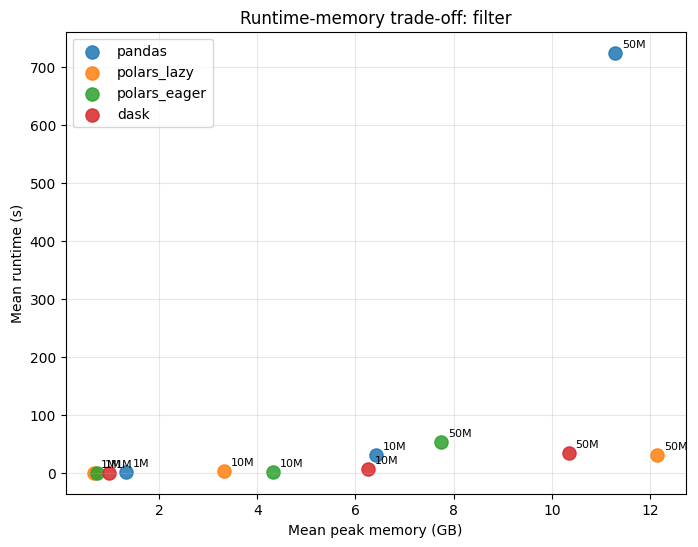

Saved: D:\Polar vs Dask\results\figures\notebook_02_real_row_scaling\runtime_memory_tradeoff_filter.png


In [ ]:
plot_runtime_memory_tradeoff_for_workload("filter")

### Filter Runtime–Memory Trade-off

Biểu đồ này so sánh trade-off giữa mean runtime và peak memory cho workload `filter`. Điểm nằm càng gần góc dưới bên trái thì càng tốt, vì vừa chạy nhanh hơn vừa dùng ít memory hơn.

Ở dataset nhỏ (`1M` và `10M`), các framework ngoài Pandas đều có runtime thấp, và khác biệt chủ yếu nằm ở memory/runtime overhead. Tuy nhiên, tại `50M`, trade-off trở nên rõ hơn.

Tại `50M`, `polars_lazy` có runtime thấp nhất, khoảng `30.6s`, nhưng dùng peak memory cao nhất, khoảng `12.15 GB`. `dask` có runtime rất cạnh tranh, khoảng `33.8s`, với peak memory thấp hơn `polars_lazy`, khoảng `10.34 GB`. Trong khi đó, `polars_eager` dùng ít memory nhất, khoảng `7.75 GB`, nhưng runtime tăng lên khoảng `53.2s`.

Pandas là outlier rõ rệt tại `50M`: runtime tăng lên khoảng `724s`, cao hơn rất nhiều so với các framework còn lại, trong khi peak memory cũng ở mức cao.

Vì vậy, với `filter` tại scale lớn, lựa chọn phụ thuộc vào constraint thực tế:

- Ưu tiên runtime: `polars_lazy`.
- Cân bằng runtime và memory: `dask`.
- Ưu tiên memory thấp hơn: `polars_eager`.
- Tránh Pandas nếu workload cần xử lý `50M` rows trong thời gian hợp lý.

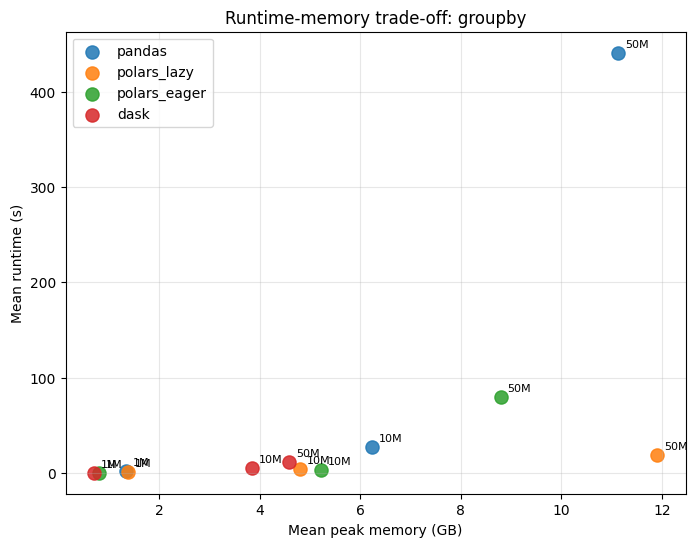

Saved: D:\Polar vs Dask\results\figures\notebook_02_real_row_scaling\runtime_memory_tradeoff_groupby.png


In [ ]:
plot_runtime_memory_tradeoff_for_workload("groupby")

### GroupBy Runtime–Memory Trade-off

Trong workload `groupby`, điểm tốt hơn là điểm gần góc dưới bên trái hơn, tức là vừa runtime thấp vừa peak memory thấp.

Tại `50M`, `dask` là lựa chọn nổi bật nhất vì vừa có runtime thấp nhất vừa có peak memory thấp nhất. Đây là trường hợp trade-off rất rõ: `dask` không chỉ nhanh hơn Pandas, Polars eager và Polars lazy, mà còn dùng ít memory hơn.

`polars_lazy` có runtime tốt thứ hai tại `50M`, nhưng peak memory cao nhất trong nhóm. `polars_eager` dùng ít memory hơn `polars_lazy`, nhưng runtime cao hơn đáng kể. Pandas là outlier tại `50M` vì runtime tăng rất mạnh và memory cũng cao.

Vì vậy, với `groupby` ở scale lớn, `dask` là recommendation mạnh nhất trong cấu hình benchmark hiện tại. Nếu không dùng Dask, `polars_lazy` là lựa chọn runtime tốt hơn Polars eager, nhưng cần chấp nhận peak memory cao hơn.

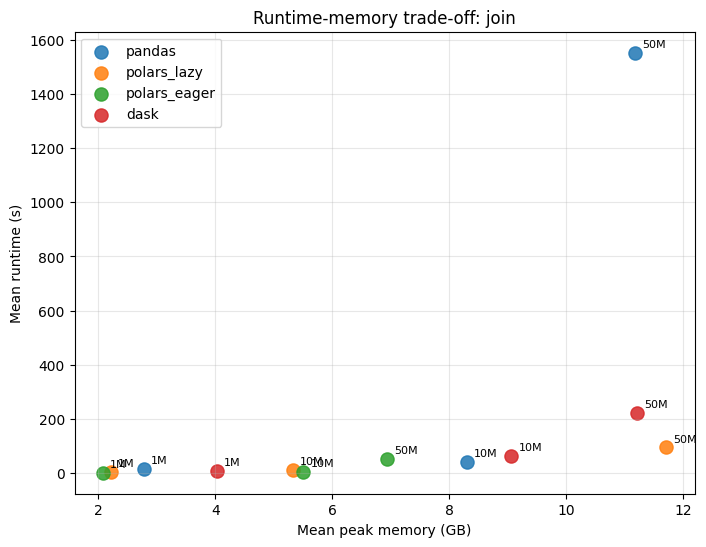

Saved: D:\Polar vs Dask\results\figures\notebook_02_real_row_scaling\runtime_memory_tradeoff_join.png


In [44]:
plot_runtime_memory_tradeoff_for_workload("join")


### Join Runtime–Memory Trade-off

Ở workload `join`, `polars_eager` là lựa chọn tốt nhất tại `50M` vì vừa có runtime thấp nhất vừa dùng peak memory thấp nhất. Đây là trường hợp recommendation khá rõ ràng: `polars_eager` tốt hơn các framework còn lại trên cả hai trục runtime và memory.

`polars_lazy` đứng thứ hai về runtime tại `50M`, nhưng dùng memory cao hơn đáng kể so với `polars_eager`. `dask` chậm hơn `polars_lazy` và có memory gần với Pandas ở `50M`. Pandas là outlier rõ nhất vì runtime tăng rất mạnh, lên hơn `1500s`.

Điều này cho thấy workload `join` trong cấu hình benchmark hiện tại là materialization-heavy và không hưởng lợi đủ từ lazy execution để vượt `polars_eager`. Vì vậy, với join lớn trên dữ liệu này, `polars_eager` là recommendation mạnh nhất.


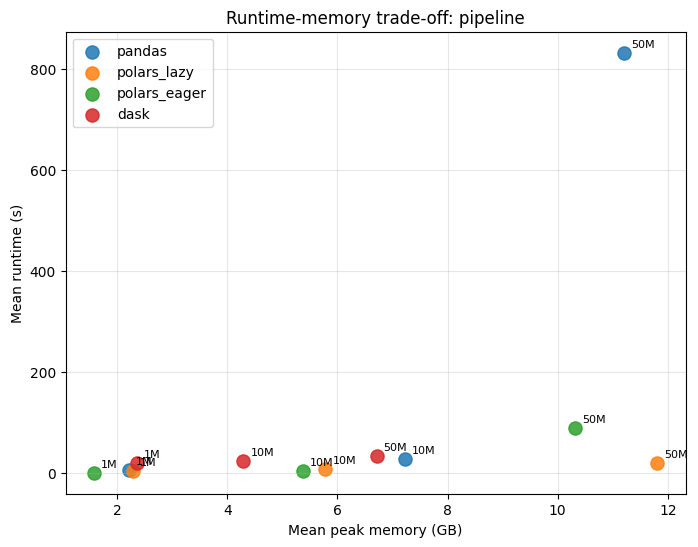

Saved: D:\Polar vs Dask\results\figures\notebook_02_real_row_scaling\runtime_memory_tradeoff_pipeline.png


In [ ]:
plot_runtime_memory_tradeoff_for_workload("pipeline")

### Pipeline Runtime–Memory Trade-off

Ở workload `pipeline`, trade-off tại `50M` khá rõ. `polars_lazy` có runtime thấp nhất, khoảng `21.17s`, nhưng dùng peak memory cao nhất, khoảng `11.81 GB`. Ngược lại, `dask` chậm hơn `polars_lazy` nhưng dùng ít memory hơn đáng kể, khoảng `6.71 GB`.

`polars_eager` tại `50M` không còn giữ lợi thế như ở dataset nhỏ hơn: runtime cao hơn `polars_lazy` và `dask`, trong khi memory cũng không thấp bằng `dask`. Pandas là outlier vì runtime tăng rất mạnh, lên hơn `800s`, và peak memory cũng cao.

Điều này cho thấy `pipeline` là workload mà lazy execution có lợi thế lớn về runtime, nhiều khả năng nhờ tối ưu toàn bộ query plan, giảm intermediate data, hoặc tối ưu projection/filter trước các bước sau. Tuy nhiên, nếu môi trường chạy bị giới hạn RAM, `dask` là lựa chọn cân bằng hơn vì tiết kiệm memory hơn đáng kể.

Vì vậy, với `pipeline` ở scale lớn: ưu tiên tốc độ thì chọn `polars_lazy`; ưu tiên memory hoặc môi trường RAM giới hạn thì cân nhắc `dask`.### Pipeline Trade-off

Ở `pipeline`, `polars_lazy` dẫn đầu runtime tại `50M`, còn Dask có memory thấp hơn. Đây là workload cần đọc như end-to-end pipeline, vì operator order và output materialization có thể làm runtime không tăng cùng tốc độ với input rows.


## 16. Stability / Variance Analysis

Mean runtime không đủ để so sánh framework. Một framework nhanh trung bình nhưng variance cao có thể khó dự đoán hơn trong workload gần production.

Notebook dùng coefficient of variation:

`runtime_cv = std_time_s / mean_time_s`

`memory_cv = std_peak_memory_gb / mean_peak_memory_gb`


In [46]:
stability = (
    summary
    [[
        "framework", "workload", "dataset_size", "row_count_m",
        "mean_time_s", "std_time_s", "runtime_cv",
        "mean_peak_memory_gb", "std_peak_memory_gb", "memory_cv",
        "n_runs",
    ]]
    .sort_values(["workload", "dataset_size", "runtime_cv"], ascending=[True, True, False])
)

display(stability.round(4))

stability_flags = stability[(stability["runtime_cv"] > 0.10) | (stability["memory_cv"] > 0.10)].copy()
if stability_flags.empty:
    print("No framework/workload/row-count cells have runtime_cv or memory_cv above 0.10.")
else:
    print("Cells with runtime_cv or memory_cv above 0.10:")
    display(stability_flags.round(4))


,framework,workload,dataset_size,row_count_m,mean_time_s,std_time_s,runtime_cv,mean_peak_memory_gb,std_peak_memory_gb,memory_cv,n_runs
2,polars_eager,filter,1M,1.0,0.3171,0.0081,0.0257,0.7459,0.0624,0.0836,3
0,pandas,filter,1M,1.0,2.0523,0.0450,0.0219,1.3245,0.0135,0.0102,3
3,dask,filter,1M,1.0,0.6916,0.0117,0.0169,0.9832,0.0360,0.0366,3
1,polars_lazy,filter,1M,1.0,0.3709,0.0029,0.0078,0.6722,0.0162,0.0241,3
16,pandas,filter,10M,10.0,31.5136,3.6559,0.1160,6.4223,0.0136,0.0021,3
18,polars_eager,filter,10M,10.0,1.7928,0.0747,0.0417,4.3202,0.1067,0.0247,3
17,polars_lazy,filter,10M,10.0,3.6330,0.1491,0.0410,3.3189,0.0174,0.0052,3
19,dask,filter,10M,10.0,6.1980,0.1707,0.0275,6.2518,0.1970,0.0315,3
35,dask,filter,50M,50.0,33.8028,3.3175,0.0981,10.3410,0.2330,0.0225,3
33,polars_lazy,filter,50M,50.0,30.5940,1.2912,0.0422,12.1515,0.1881,0.0155,3


Cells with runtime_cv or memory_cv above 0.10:


,framework,workload,dataset_size,row_count_m,mean_time_s,std_time_s,runtime_cv,mean_peak_memory_gb,std_peak_memory_gb,memory_cv,n_runs
16,pandas,filter,10M,10.0,31.5136,3.6559,0.1160,6.4223,0.0136,0.0021,3
20,pandas,groupby,10M,10.0,27.2748,4.6525,0.1706,6.2253,0.0567,0.0091,3
9,polars_lazy,join,1M,1.0,5.2984,1.5176,0.2864,2.2089,0.0628,0.0284,3
11,dask,join,1M,1.0,8.0048,1.6837,0.2103,4.0314,0.0511,0.0127,3
8,pandas,join,1M,1.0,14.1695,2.6114,0.1843,2.7787,0.0652,0.0235,3
24,pandas,join,10M,10.0,40.8810,7.0793,0.1732,8.3027,0.0153,0.0018,3
26,polars_eager,join,10M,10.0,3.8077,0.5562,0.1461,5.5073,0.1098,0.0199,3
27,dask,join,10M,10.0,63.6579,7.6178,0.1197,9.0658,0.3952,0.0436,3
42,polars_eager,join,50M,50.0,53.3953,4.4614,0.0836,6.9338,0.8088,0.1166,3
12,pandas,pipeline,1M,1.0,6.5788,1.2556,0.1909,2.2172,0.0167,0.0075,3


### Runtime and Memory Variability Interpretation

Bảng này dùng hệ số biến thiên, `CV = std / mean`, để đánh giá độ ổn định giữa các lần chạy. `runtime_cv` đo mức dao động tương đối của runtime, còn `memory_cv` đo mức dao động tương đối của peak memory. Vì mỗi cấu hình chỉ có `n_runs = 3`, CV nên được đọc như một chỉ báo ổn định sơ bộ, không phải kiểm định thống kê đầy đủ.

Các cell có `runtime_cv` hoặc `memory_cv` lớn hơn `0.10` chủ yếu xuất hiện ở dataset nhỏ hoặc workload nặng như `join`. Điều này hợp lý vì ở dataset nhỏ, fixed overhead, OS cache, disk cache, process startup, scheduler overhead hoặc allocation ban đầu có thể chiếm tỷ trọng lớn trong tổng runtime. Khi mean runtime nhỏ, chỉ một dao động nhỏ tuyệt đối cũng có thể tạo ra CV tương đối cao.

Ở các workload nặng như `join`, variance cao hơn có thể đến từ chi phí materialization, memory allocation, cache state, hoặc khác biệt trong cách framework xử lý key matching và intermediate data. Ví dụ, một số run `join` ở `1M` hoặc `10M` có runtime CV cao hơn các workload đơn giản hơn.

Tuy nhiên, các kết luận chính ở `50M` vẫn khá vững vì khác biệt giữa các framework thường rất lớn so với mức dao động giữa ba lần chạy. Ví dụ, trong `50M join`, Pandas chậm hơn rất nhiều so với Polars eager; trong `50M groupby`, Dask nhanh hơn rõ rệt và dùng ít memory hơn; trong `50M pipeline`, Polars lazy và Dask vượt Pandas rất xa.

Do đó, variance analysis nên được dùng để cảnh báo khi so sánh các framework có kết quả gần nhau. Nếu hai framework chỉ chênh lệch nhỏ nhưng CV cao, không nên kết luận quá mạnh. Ngược lại, khi chênh lệch runtime hoặc memory lớn và nhất quán, kết luận có độ tin cậy thực tế cao hơn.

## 17. Scaling Slopes

Scaling slope ước lượng độ nhạy runtime theo số dòng bằng hồi quy log-log:

`log(runtime) = slope × log(row_count) + intercept`

Slope gần `1.0` gợi ý runtime tăng gần tuyến tính theo số dòng. Slope lớn hơn `1.0` gợi ý super-linear slowdown. Slope thấp hơn `1.0` có thể do fixed overhead ở input nhỏ, output nhỏ hơn input, hoặc execution model tận dụng input lớn hiệu quả hơn.


In [47]:
slope_rows = []

for (framework, workload), group in summary.groupby(["framework", "workload"], observed=True):
    group = group.dropna(subset=["row_count_m", "mean_time_s"])
    group = group[(group["row_count_m"] > 0) & (group["mean_time_s"] > 0)]

    if len(group) >= 2:
        x = np.log(group["row_count_m"].to_numpy())
        y = np.log(group["mean_time_s"].to_numpy())

        slope, intercept = np.polyfit(x, y, 1)
        y_pred = slope * x + intercept

        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        slope_rows.append({
            "framework": framework,
            "workload": workload,
            "runtime_scaling_slope": slope,
            "r_squared": r_squared,
            "n_points": len(group),
            "min_row_count_m": group["row_count_m"].min(),
            "max_row_count_m": group["row_count_m"].max(),
        })

slope_summary = pd.DataFrame(slope_rows).sort_values(["workload", "runtime_scaling_slope"])
display(slope_summary.round(3))


,framework,workload,runtime_scaling_slope,r_squared,n_points,min_row_count_m,max_row_count_m
12,dask,filter,0.991,0.999,3,1.0,50.0
4,polars_lazy,filter,1.119,0.993,3,1.0,50.0
8,polars_eager,filter,1.271,0.920,3,1.0,50.0
0,pandas,filter,1.478,0.980,3,1.0,50.0
5,polars_lazy,groupby,0.868,0.999,3,1.0,50.0
13,dask,groupby,0.932,0.957,3,1.0,50.0
1,pandas,groupby,1.289,0.977,3,1.0,50.0
9,polars_eager,groupby,1.298,0.937,3,1.0,50.0
6,polars_lazy,join,0.705,0.846,3,1.0,50.0
14,dask,join,0.854,0.998,3,1.0,50.0


### Runtime Scaling Slope Interpretation

Bảng này ước lượng xu hướng scaling bằng cách fit quan hệ log-log giữa row count và mean runtime. `runtime_scaling_slope` có thể đọc như mức tăng runtime tương đối khi row count tăng, nhưng chỉ nên xem là chỉ báo chẩn đoán xu hướng.

Cách đọc khái quát:

- Slope gần `1.0`: runtime tăng gần tuyến tính theo row count.
- Slope lớn hơn `1.0`: runtime tăng nhanh hơn tuyến tính.
- Slope nhỏ hơn `1.0`: runtime tăng chậm hơn row count, có thể do fixed overhead được amortize, parallelism tốt hơn ở dataset lớn, hoặc workload giảm dữ liệu sau các bước xử lý.
- `r_squared` cho biết đường log-log fit khớp với ba điểm dữ liệu đến mức nào.

Tuy nhiên, vì chỉ có `3` row-count points (`1M`, `10M`, `50M`), các slope này không nên được diễn giải như bằng chứng về độ phức tạp thuật toán. Chúng chỉ giúp tóm tắt xu hướng scaling quan sát được trong benchmark end-to-end hiện tại.

Trong kết quả này, Pandas thường có slope cao hơn Polars/Dask ở nhiều workload, đặc biệt ở `filter`, `groupby`, và `pipeline`, cho thấy runtime của Pandas tăng nhanh hơn khi row count lớn. Ngược lại, một số trường hợp như `dask pipeline` và `polars_lazy pipeline` có slope thấp, phù hợp với đặc điểm pipeline: các bước filter/groupby có thể giảm dữ liệu trước khi materialize kết quả cuối, nên runtime không nhất thiết tăng cùng tốc độ với input rows.

Vì vậy, slope nên được dùng để phát hiện khác biệt lớn về xu hướng scaling, không nên dùng để kết luận tuyệt đối rằng framework có độ phức tạp thuật toán tốt hơn.

## 18. Workload Sensitivity at 50M

Phần này nhìn riêng `50M`, vì đây là điểm thể hiện rõ nhất khác biệt khi row count lớn. Mục tiêu là xem workload nào là bottleneck cho từng framework.


In [48]:
max_row_label = "50M" if "50M" in summary["dataset_size"].astype(str).unique() else summary.sort_values("row_count_m")["dataset_size"].astype(str).iloc[-1]

workload_sensitivity = (
    summary[summary["dataset_size"].astype(str) == max_row_label]
    .sort_values(["framework", "mean_time_s"], ascending=[True, False])
    [["framework", "workload", "dataset_size", "mean_time_s", "mean_peak_memory_gb", "mean_throughput_mrows_per_s"]]
)

workload_sensitivity["runtime_share_within_framework"] = (
    workload_sensitivity["mean_time_s"]
    / workload_sensitivity.groupby("framework", observed=True)["mean_time_s"].transform("sum")
)

display(workload_sensitivity.round(3))


,framework,workload,dataset_size,mean_time_s,mean_peak_memory_gb,mean_throughput_mrows_per_s,runtime_share_within_framework
40,pandas,join,50M,1552.661,11.182,0.032,0.437
44,pandas,pipeline,50M,832.445,11.210,0.060,0.234
32,pandas,filter,50M,724.352,11.296,0.069,0.204
36,pandas,groupby,50M,440.839,11.132,0.114,0.124
41,polars_lazy,join,50M,94.129,11.716,0.532,0.572
33,polars_lazy,filter,50M,30.594,12.151,1.636,0.186
45,polars_lazy,pipeline,50M,21.170,11.810,2.362,0.129
37,polars_lazy,groupby,50M,18.763,11.910,2.666,0.114
46,polars_eager,pipeline,50M,89.544,10.322,0.560,0.325
38,polars_eager,groupby,50M,79.645,8.792,0.628,0.289


### 50M Workload Bottleneck Interpretation

Bảng này chỉ xét các workload tại `50M` và cho biết workload nào chiếm nhiều runtime nhất trong từng framework.  
Cột `runtime_share_within_framework` là tỷ trọng runtime của một workload so với tổng runtime của framework đó trên bốn workload tại `50M`.

Kết quả cho thấy bottleneck khác nhau rõ rệt theo framework:

| Framework | Main bottleneck at 50M | Interpretation |
|---|---|---|
| `pandas` | `join` | `join` chiếm khoảng `43.7%` tổng runtime của Pandas tại `50M`, tiếp theo là `pipeline` và `filter`. |
| `polars_lazy` | `join` | Mặc dù lazy rất mạnh ở `filter`, `groupby`, và `pipeline`, `join` vẫn chiếm khoảng `57.2%` tổng runtime của Polars lazy. |
| `polars_eager` | `pipeline` / `groupby` | Eager rất mạnh ở `join`, nhưng `pipeline` và `groupby` chiếm tỷ trọng runtime lớn hơn. |
| `dask` | `join` | `join` chiếm khoảng `73.8%` tổng runtime của Dask tại `50M`, dù Dask rất mạnh ở `groupby` và khá tốt ở `pipeline`. |

Điều này cho thấy không nên kết luận một framework duy nhất là tốt nhất cho mọi trường hợp. Mỗi framework có điểm mạnh và bottleneck khác nhau:

- Pandas bị kéo mạnh bởi `join`, `pipeline`, và `filter` ở scale lớn.
- Polars lazy rất hiệu quả cho `filter`, `groupby`, và `pipeline`, nhưng `join` là điểm nghẽn chính.
- Polars eager là lựa chọn mạnh cho `join`, nhưng kém cạnh tranh hơn ở `groupby` và `pipeline` tại `50M`.
- Dask nổi bật ở `groupby` và có trade-off tốt ở `pipeline`, nhưng `join` vẫn là workload tốn runtime nhất.

Vì vậy, kết luận thực tế nên được viết theo workload và constraint tài nguyên, thay vì chọn một framework thắng tuyệt đối.

## 19. Failure Analysis

Failure không được trộn vào mean runtime. Nếu có failure, phần này tách riêng để đánh giá stability boundary. Trong dữ liệu hiện có, các file real row scaling đều ghi nhận successful runs.


In [49]:
if df_fail.empty:
    failure_summary = pd.DataFrame(columns=["framework", "workload", "dataset_size", "n_fail", "statuses", "notes"])
    print("No failed runs were recorded in the loaded real row-scaling files.")
else:
    failure_summary = (
        df_fail
        .groupby(["framework", "workload", "dataset_size"], observed=True)
        .agg(
            n_fail=("status", "count"),
            statuses=("status", lambda values: ", ".join(sorted(set(map(str, values))))),
            notes=("notes", lambda values: " | ".join(sorted(set(str(value) for value in values if pd.notna(value))))),
        )
        .reset_index()
    )
    display(failure_summary)


No failed runs were recorded in the loaded real row-scaling files.


## 20. Limitations

Benchmark này cần được đọc với các giới hạn sau:

1. Chỉ có ba row-count points: `1M`, `10M`, và `50M`. Vì vậy, các slope/log-log scaling estimates chỉ là chỉ báo xu hướng, không phải mô hình thống kê đầy đủ hay bằng chứng về độ phức tạp thuật toán.

2. Mỗi cấu hình có `3` successful runs. Điều này đủ cho so sánh thực nghiệm cơ bản và phát hiện khác biệt lớn, nhưng vẫn hạn chế cho statistical inference mạnh. Ranking nên được hiểu là ranking trong dữ liệu benchmark hiện tại.

3. Đây là end-to-end benchmark, nên runtime bao gồm đọc parquet, parquet decoding, query execution, scheduling/optimization overhead, memory allocation, intermediate data construction và final result materialization. Vì vậy, kết quả không nên được diễn giải như pure operator benchmark hoặc pure engine benchmark.

4. Row count là biến scaling chính được kiểm soát, nhưng physical footprint vẫn có thể thay đổi theo nội dung real data subset, compression ratio, string length distribution, cardinality, row group layout và số parquet files. Do đó, notebook này là real row-scaling benchmark, không thay thế physical-size scaling benchmark.

5. Peak memory là metric thực nghiệm end-to-end và có thể bị ảnh hưởng bởi cách đo RSS/process memory, native allocation của Polars, worker/task execution của Dask, cache, garbage collection và thời điểm materialize kết quả. Vì vậy, peak memory phù hợp để so sánh áp lực tài nguyên tổng thể hơn là so sánh memory allocator nội bộ của từng framework.

6. Kết quả phản ánh workload semantics trong benchmark này: `filter`, `groupby`, `join`, và `pipeline` trên schema và dữ liệu real hiện tại. Không nên generalize trực tiếp sang mọi workload dataframe khác, đặc biệt các workload có output size, key cardinality, skew hoặc join pattern khác.

7. Kết quả phản ánh môi trường chạy hiện tại. OS/hardware comparison nên được phân tích trong notebook riêng, không trộn vào kết luận chính ở đây. Nếu Windows, Linux, hoặc Colab được chạy trên phần cứng hoặc resource policy khác nhau, kết quả đó nên được gọi là environment comparison, không phải pure OS comparison.

8. Các kết luận nên được đọc cùng với runtime, throughput, memory, variance và workload semantics. Một framework nhanh nhất không nhất thiết là lựa chọn tốt nhất nếu môi trường bị giới hạn RAM hoặc nếu workload thực tế khác với workload trong benchmark này.

## 21. Final Conclusion

Trong cấu hình benchmark hiện tại trên dữ liệu real từ `1M` đến `50M` rows, Pandas là baseline dễ dùng nhưng scale kém nhất ở dataset lớn trong hầu hết workload. Các framework còn lại nhanh hơn Pandas theo bậc độ lớn tại `50M`, nhưng ranking phụ thuộc workload.

`polars_lazy` nổi bật ở `filter` và `pipeline` tại `50M`, cho thấy lợi ích của lazy optimization trong workload scan/filter/pipeline. `polars_eager` là lựa chọn mạnh nhất cho `join`, nơi runtime thấp hơn rõ rệt so với các framework khác. `dask` nổi bật ở `groupby` và có memory behavior tốt trong một số workload nhờ partitioned execution.

Vì vậy, kết luận phù hợp cho notebook này là: real row scaling không có một framework thắng tuyệt đối; lựa chọn tốt nhất phụ thuộc workload, row count và giới hạn memory. Tuy nhiên, khi row count tăng lên `50M`, Polars và Dask đều vượt Pandas rất rõ về runtime end-to-end.


In [50]:
SUMMARY_PATH = PROJECT_ROOT / "results" / "table" / "real_row_scaling_summary.csv"
SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)

summary.to_csv(SUMMARY_PATH, index=False)
print(f"Saved summary: {SUMMARY_PATH}")


Saved summary: D:\Polar vs Dask\results\table\real_row_scaling_summary.csv
